
=== jf ===
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
c[0]       -0.750  0.043  -0.826   -0.666      0.001    0.001    1531.0   
c[1]        0.296  0.046   0.213    0.386      0.001    0.001    1440.0   
B[0]        3.213  0.242   2.782    3.686      0.007    0.005    1034.0   
B[1]        4.019  0.201   3.632    4.383      0.006    0.004    1144.0   
t0          0.048  0.012   0.025    0.069      0.000    0.000    1448.0   
d_base[0]   0.945  0.048   0.855    1.033      0.001    0.001    1513.0   
d_base[1]   0.499  0.033   0.438    0.562      0.001    0.001    2027.0   
d_base[2]   0.078  0.027   0.030    0.132      0.000    0.000    2760.0   
d_base[3]   0.037  0.025   0.000    0.080      0.000    0.000    1750.0   
d_base[4]   0.241  0.031   0.184    0.300      0.001    0.001    2391.0   
d_base[5]   0.576  0.037   0.510    0.650      0.001    0.001    1834.0   
d_base[6]   0.842  0.048   0.749    0.929      0.001    0.001    1498.0   
r          12

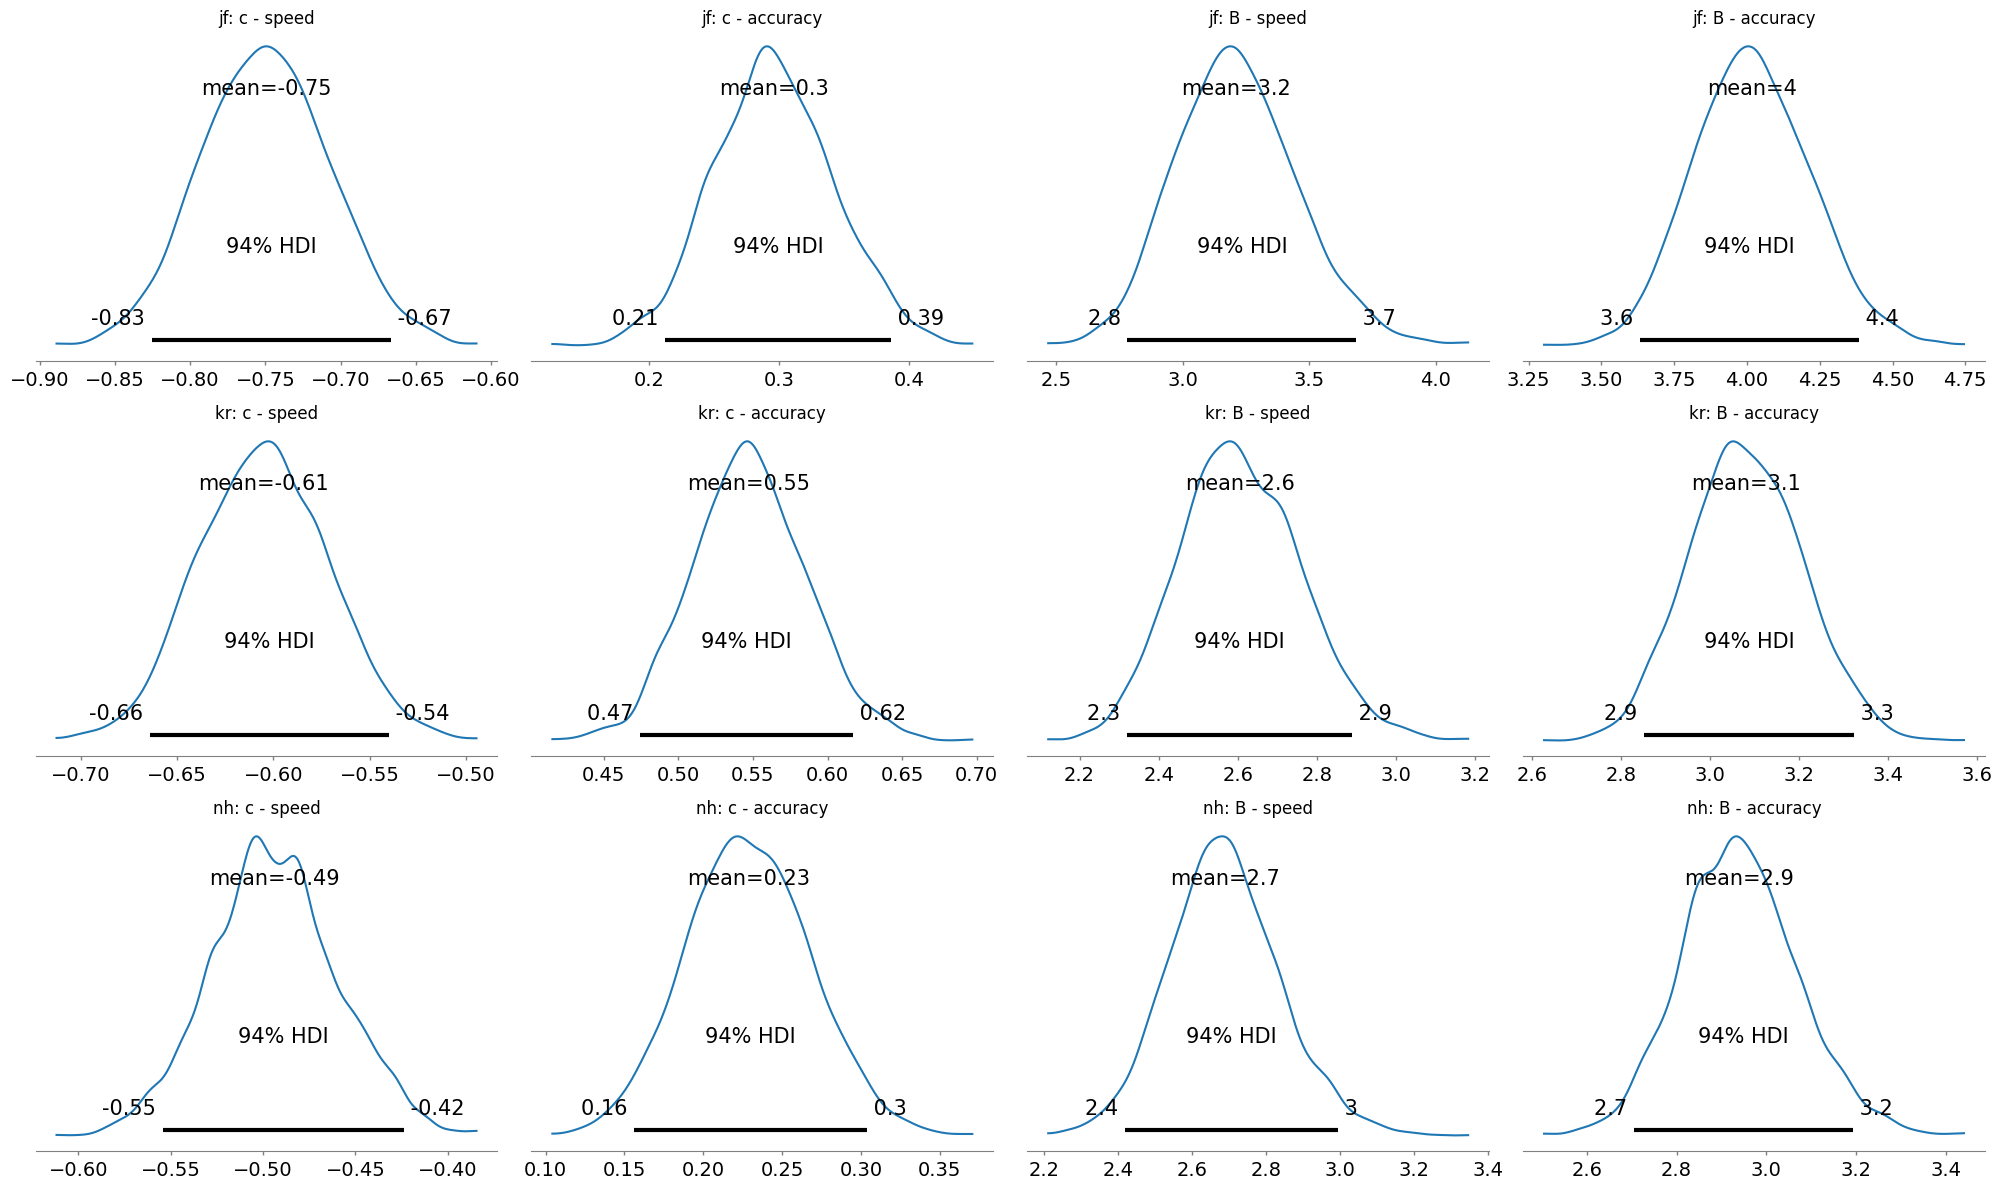

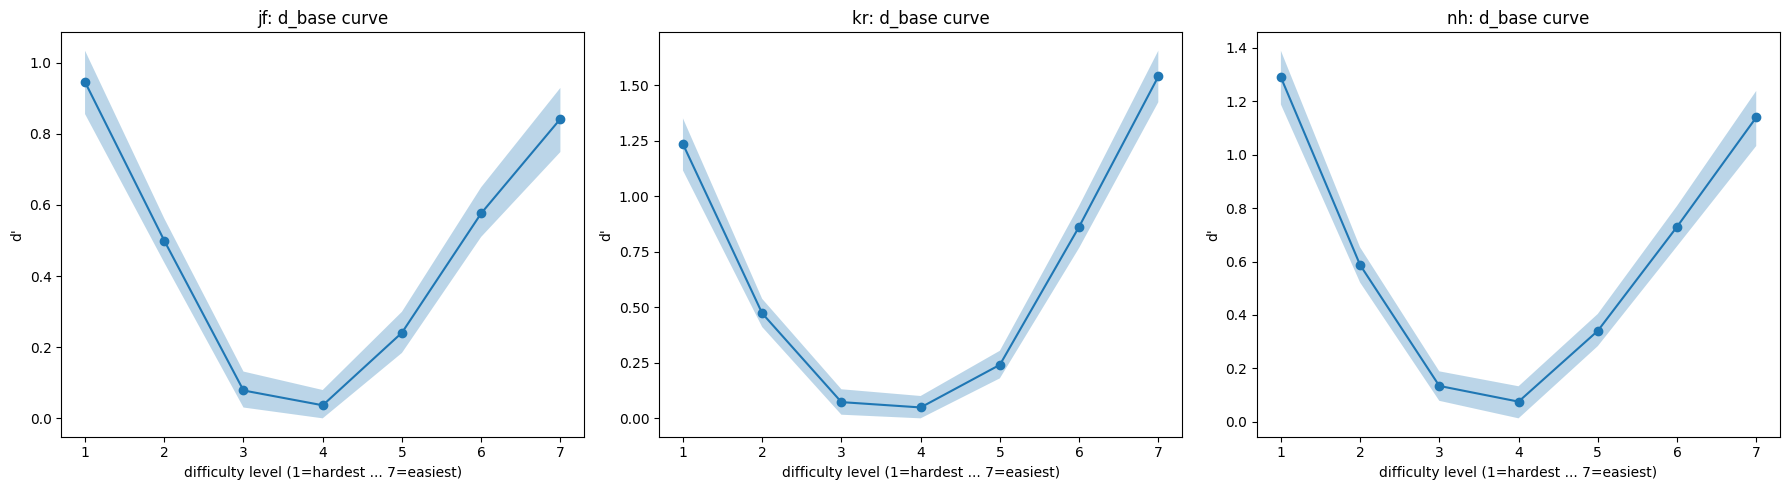

In [3]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

PARTICIPANTS = ["jf", "kr", "nh"]
IDATA_DIR = "rr98_fits/idata"

idata_c_B = {pid: az.from_netcdf(f"{IDATA_DIR}/c_B_{pid}.nc") for pid in PARTICIPANTS}

# --- summary table: c, B, t0, d_base, r, p_lapse for each participant ---
for pid in PARTICIPANTS:
    print(f"\n=== {pid} ===")
    print(az.summary(idata_c_B[pid], var_names=["c", "B", "t0", "d_base", "r", "p_lapse"]))

# --- c[speed] vs c[accuracy], B[speed] vs B[accuracy], per participant ---
fig, axes = plt.subplots(len(PARTICIPANTS), 4, figsize=(20, 4 * len(PARTICIPANTS)))
cond_labels = ["speed", "accuracy"]

for row, pid in enumerate(PARTICIPANTS):
    for j, cond in enumerate(cond_labels):
        az.plot_posterior(idata_c_B[pid], var_names=["c"], coords={"c_dim_0": [j]},
                           ax=axes[row, j])
        axes[row, j].set_title(f"{pid}: c - {cond}")

    for j, cond in enumerate(cond_labels):
        az.plot_posterior(idata_c_B[pid], var_names=["B"], coords={"B_dim_0": [j]},
                           ax=axes[row, j + 2])
        axes[row, j + 2].set_title(f"{pid}: B - {cond}")

plt.tight_layout()
plt.show()

# --- d_base difficulty curve (7 levels), per participant, mean +/- 94% HDI ---
fig, axes = plt.subplots(1, len(PARTICIPANTS), figsize=(6 * len(PARTICIPANTS), 5))

for ax, pid in zip(axes, PARTICIPANTS):
    d_base_samples = idata_c_B[pid].posterior["d_base"].values.reshape(-1, 7)
    means = d_base_samples.mean(axis=0)
    hdi = az.hdi(idata_c_B[pid], var_names=["d_base"])["d_base"].values  # shape (7, 2)

    levels = np.arange(1, 8)
    ax.plot(levels, means, marker="o")
    ax.fill_between(levels, hdi[:, 0], hdi[:, 1], alpha=0.3)
    ax.set_xlabel("difficulty level (1=hardest ... 7=easiest)")
    ax.set_ylabel("d'")
    ax.set_title(f"{pid}: d_base curve")

plt.tight_layout()
plt.show()


=== jf ===
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
c[0]       -0.782  0.042  -0.864   -0.707      0.001    0.001    1500.0   
c[1]        0.400  0.038   0.328    0.471      0.001    0.001    1449.0   
B           3.198  0.186   2.847    3.540      0.005    0.004    1565.0   
t0[0]       0.040  0.011   0.019    0.062      0.000    0.000    1431.0   
t0[1]       0.122  0.014   0.096    0.147      0.000    0.000    1560.0   
d_base[0]   0.987  0.044   0.905    1.070      0.001    0.001    2339.0   
d_base[1]   0.527  0.033   0.463    0.588      0.001    0.000    2318.0   
d_base[2]   0.082  0.029   0.032    0.140      0.001    0.001    2120.0   
d_base[3]   0.039  0.025   0.000    0.082      0.000    0.000    1842.0   
d_base[4]   0.255  0.032   0.190    0.310      0.001    0.001    2546.0   
d_base[5]   0.607  0.036   0.538    0.675      0.001    0.001    2173.0   
d_base[6]   0.887  0.048   0.798    0.979      0.001    0.001    2457.0   
r          12

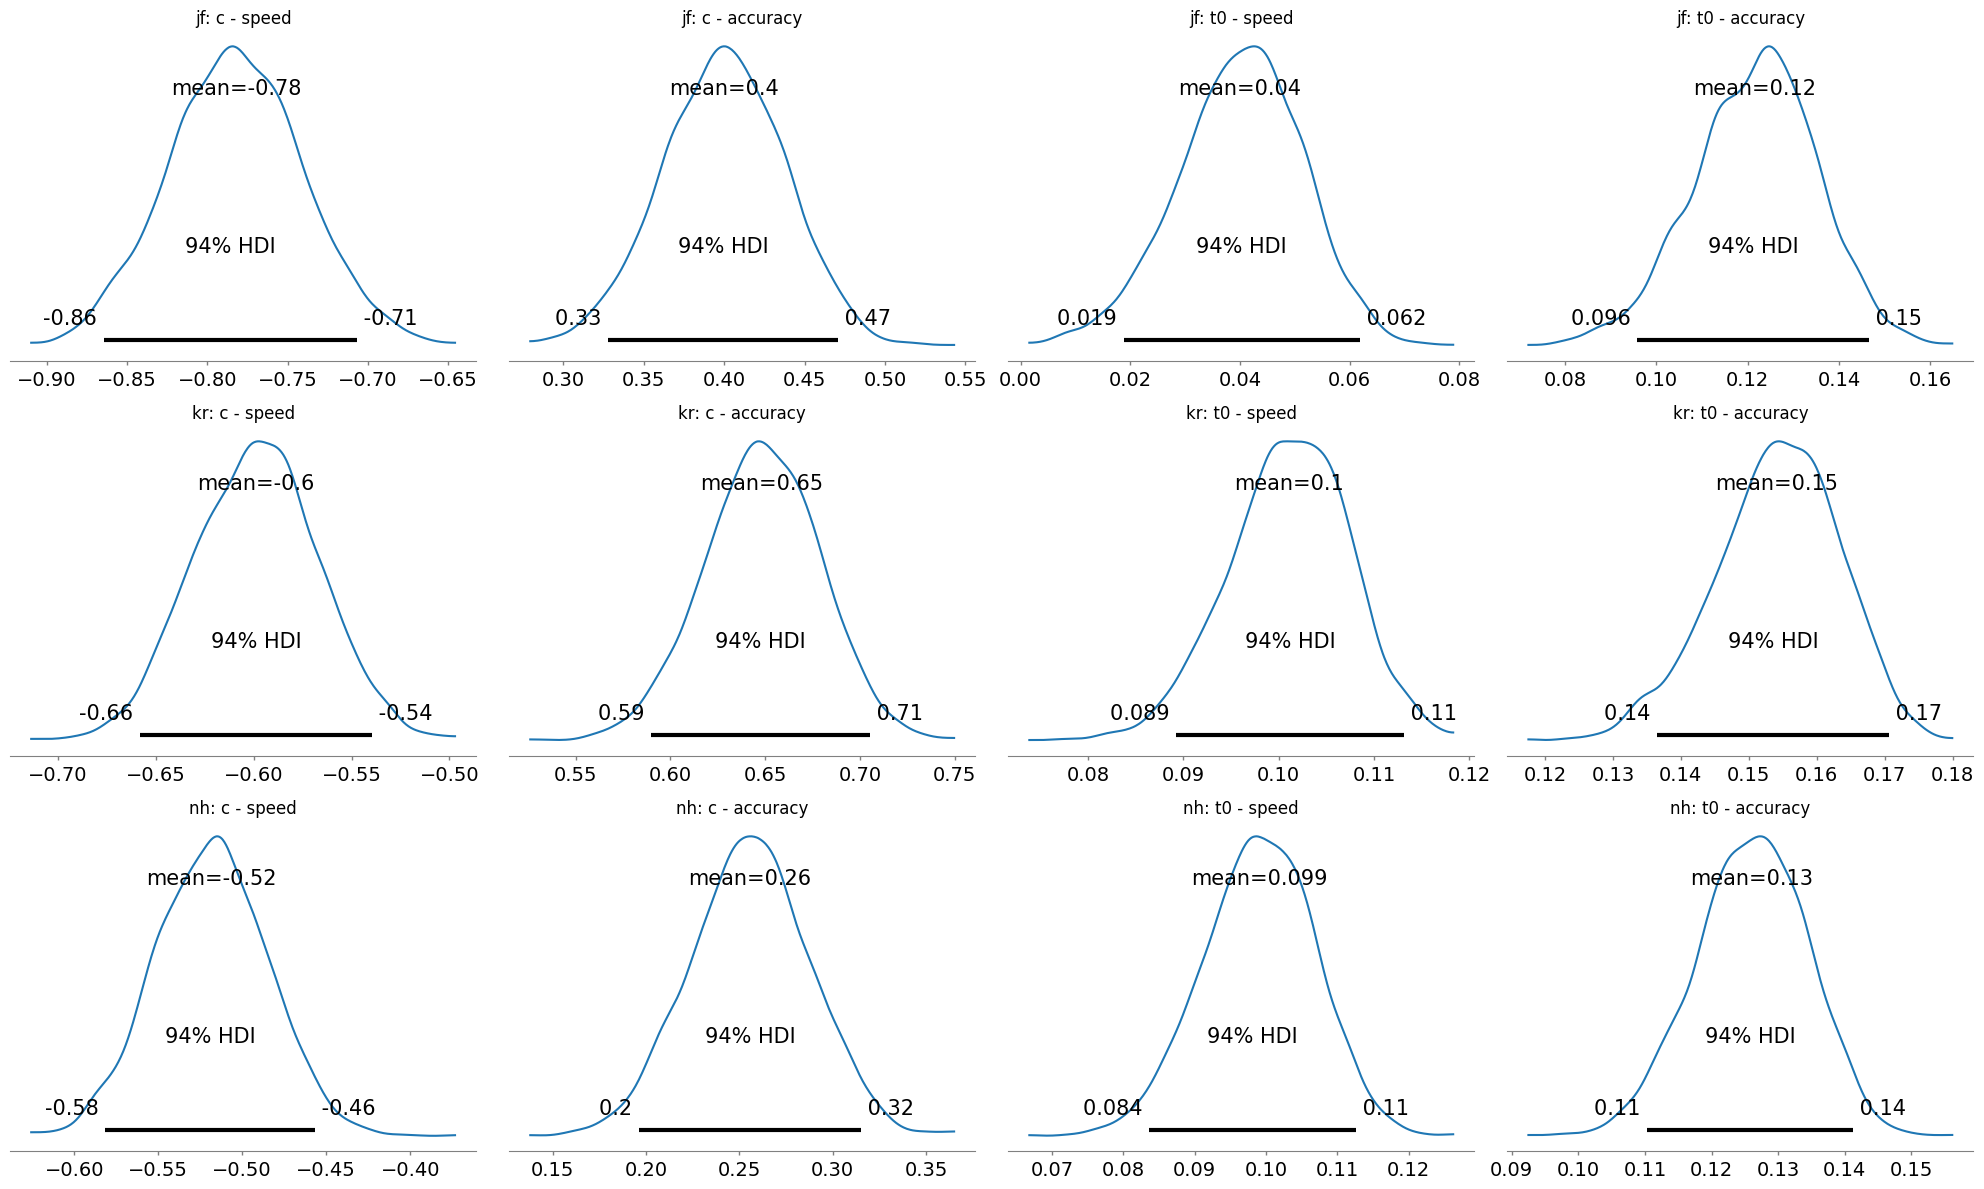

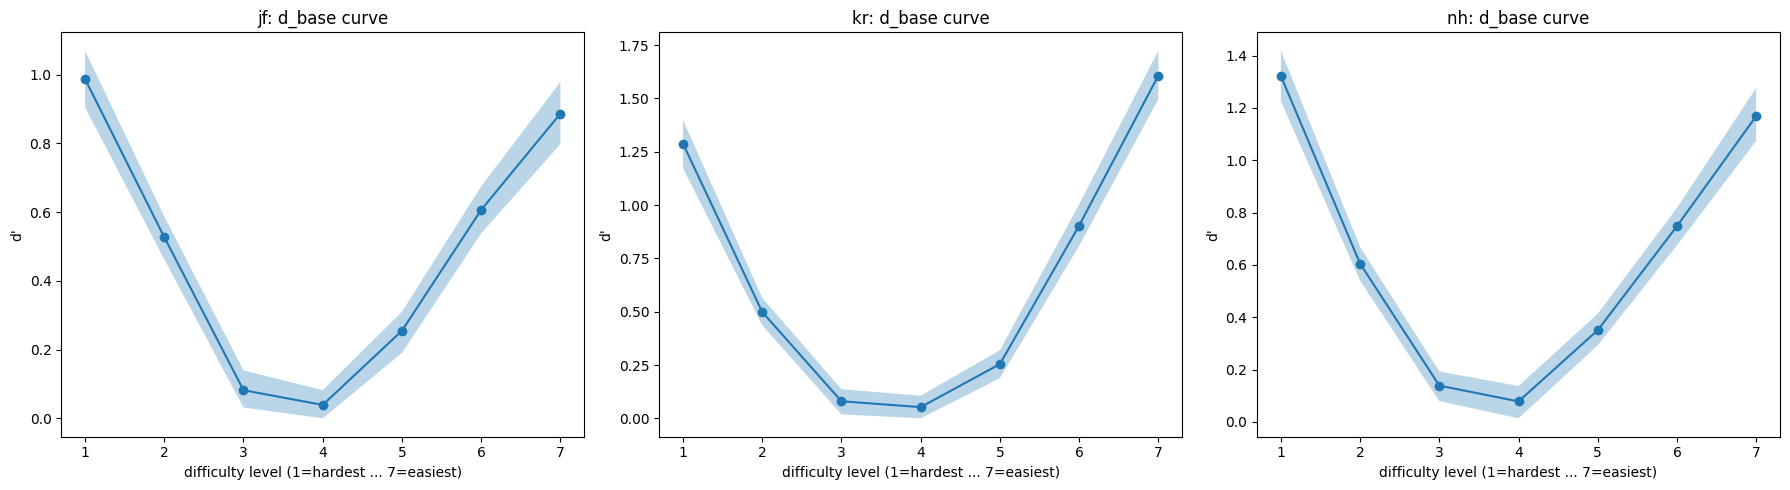

In [7]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

PARTICIPANTS = ["jf", "kr", "nh"]
IDATA_DIR = "rr98_fits/idata"

idata_c_B = {pid: az.from_netcdf(f"{IDATA_DIR}/c_t0_{pid}.nc") for pid in PARTICIPANTS}

# --- summary table: c, B, t0, d_base, r, p_lapse for each participant ---
for pid in PARTICIPANTS:
    print(f"\n=== {pid} ===")
    print(az.summary(idata_c_B[pid], var_names=["c", "B", "t0", "d_base", "r", "p_lapse"]))

# --- c[speed] vs c[accuracy], B[speed] vs B[accuracy], per participant ---
fig, axes = plt.subplots(len(PARTICIPANTS), 4, figsize=(20, 4 * len(PARTICIPANTS)))
cond_labels = ["speed", "accuracy"]

for row, pid in enumerate(PARTICIPANTS):
    for j, cond in enumerate(cond_labels):
        az.plot_posterior(idata_c_B[pid], var_names=["c"], coords={"c_dim_0": [j]},
                           ax=axes[row, j])
        axes[row, j].set_title(f"{pid}: c - {cond}")

    for j, cond in enumerate(cond_labels):
        az.plot_posterior(idata_c_B[pid], var_names=["t0"], coords={"t0_dim_0": [j]},
                           ax=axes[row, j + 2])
        axes[row, j + 2].set_title(f"{pid}: t0 - {cond}")

plt.tight_layout()
plt.show()

# --- d_base difficulty curve (7 levels), per participant, mean +/- 94% HDI ---
fig, axes = plt.subplots(1, len(PARTICIPANTS), figsize=(6 * len(PARTICIPANTS), 5))

for ax, pid in zip(axes, PARTICIPANTS):
    d_base_samples = idata_c_B[pid].posterior["d_base"].values.reshape(-1, 7)
    means = d_base_samples.mean(axis=0)
    hdi = az.hdi(idata_c_B[pid], var_names=["d_base"])["d_base"].values  # shape (7, 2)

    levels = np.arange(1, 8)
    ax.plot(levels, means, marker="o")
    ax.fill_between(levels, hdi[:, 0], hdi[:, 1], alpha=0.3)
    ax.set_xlabel("difficulty level (1=hardest ... 7=easiest)")
    ax.set_ylabel("d'")
    ax.set_title(f"{pid}: d_base curve")

plt.tight_layout()
plt.show()

In [77]:
df[(df["strength"]>31) & (df["source"]=="dark")]

,id,session,block,trial,instruction,source,strength,response,response_num,correct,rt,outlier
259,jf,2,3,78,speed,dark,32,light,2,False,0.336,False
8147,kr,2,3,78,speed,dark,32,light,2,False,0.255,False
9722,kr,4,3,78,speed,dark,32,light,2,False,0.301,False



=== jf ===
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
c         -0.216  0.024  -0.260   -0.168      0.001    0.000    1338.0   
B[0]       0.999  0.050   0.904    1.092      0.002    0.001     774.0   
B[1]       2.356  0.108   2.155    2.557      0.004    0.003     738.0   
t0         0.154  0.003   0.149    0.160      0.000    0.000    2039.0   
d_base[0]  1.765  0.070   1.635    1.899      0.002    0.001     959.0   
d_base[1]  1.215  0.074   1.082    1.358      0.002    0.001     876.0   
d_base[2]  0.539  0.067   0.412    0.662      0.002    0.001    1222.0   
d_base[3]  0.415  0.072   0.281    0.548      0.002    0.001    1343.0   
d_base[4]  0.784  0.072   0.649    0.913      0.002    0.001    1033.0   
d_base[5]  1.291  0.074   1.148    1.427      0.003    0.001     880.0   
d_base[6]  1.686  0.080   1.536    1.835      0.003    0.002     867.0   
delta_d   -0.479  0.050  -0.574   -0.386      0.002    0.001     846.0   
r          6.388  0.365   

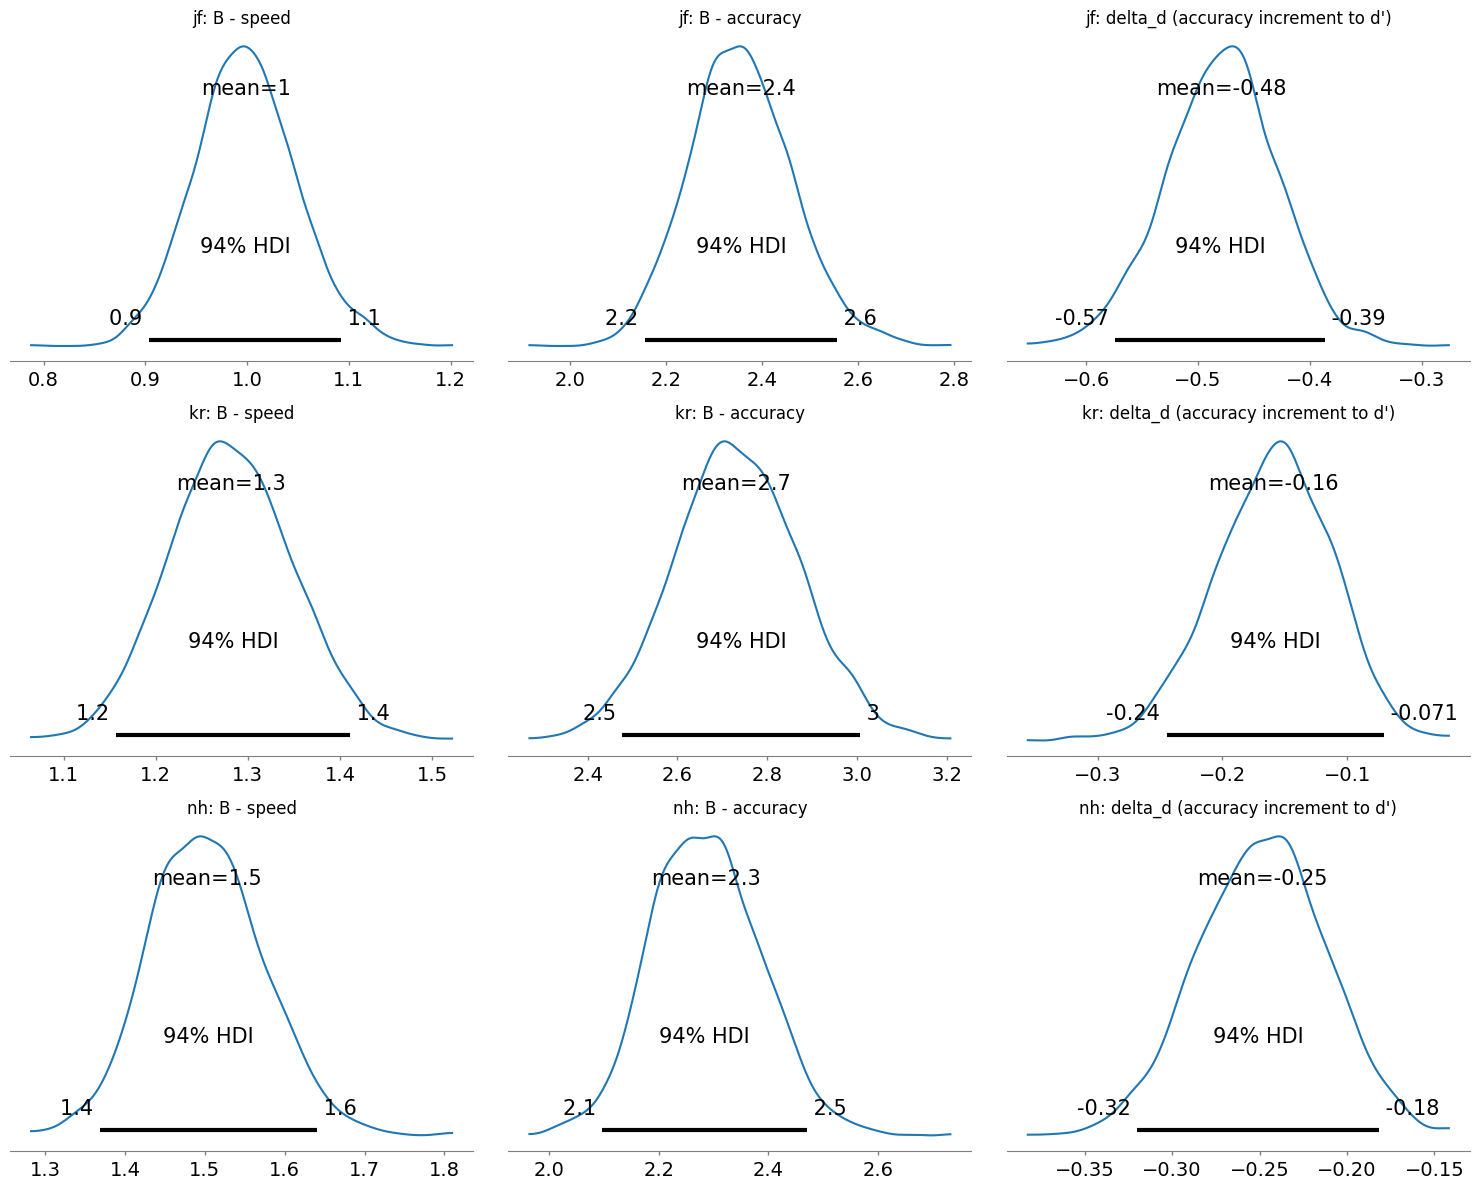

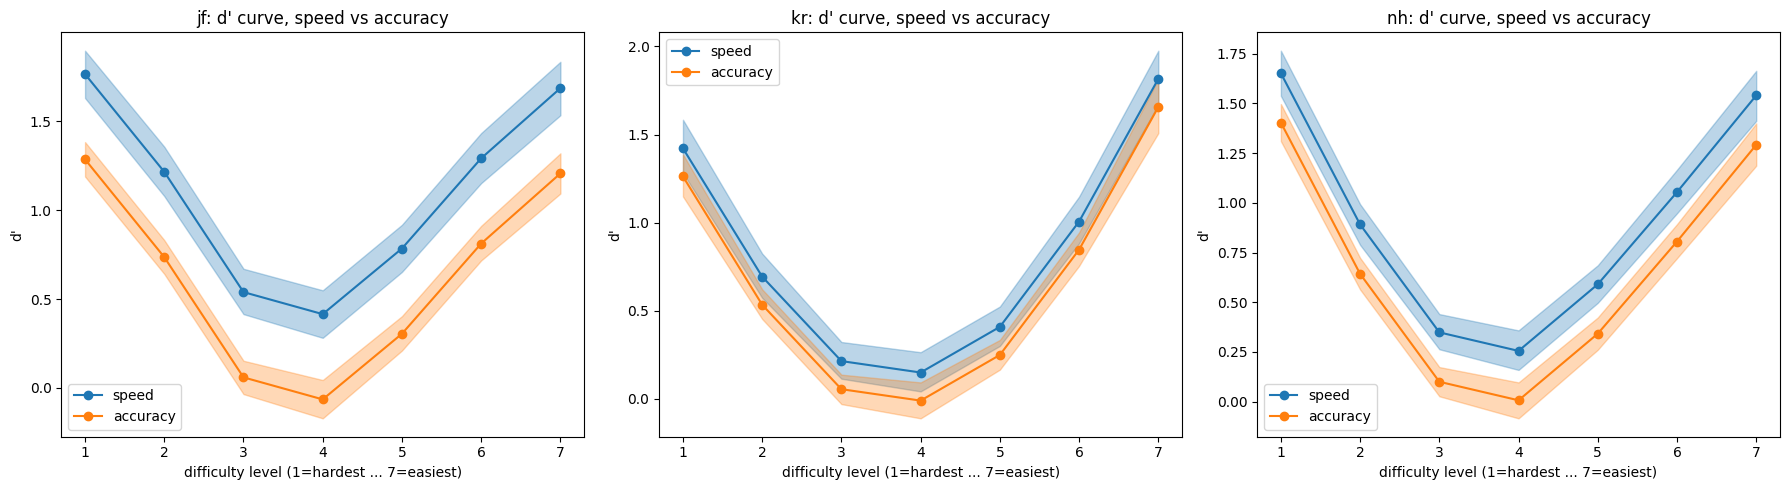

In [22]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

PARTICIPANTS = ["jf", "kr", "nh"]
IDATA_DIR = "rr98_fits/idata"

idata_d_B = {pid: az.from_netcdf(f"{IDATA_DIR}/d_B_{pid}.nc") for pid in PARTICIPANTS}

# --- summary table, now including delta_d ---
for pid in PARTICIPANTS:
    print(f"\n=== {pid} ===")
    print(az.summary(idata_d_B[pid], var_names=["c", "B", "t0", "d_base", "delta_d", "r", "p_lapse"]))

# --- B[speed] vs B[accuracy], and delta_d, per participant ---
fig, axes = plt.subplots(len(PARTICIPANTS), 3, figsize=(15, 4 * len(PARTICIPANTS)))
cond_labels = ["speed", "accuracy"]

for row, pid in enumerate(PARTICIPANTS):
    for j, cond in enumerate(cond_labels):
        az.plot_posterior(idata_d_B[pid], var_names=["B"], coords={"B_dim_0": [j]},
                           ax=axes[row, j])
        axes[row, j].set_title(f"{pid}: B - {cond}")

    az.plot_posterior(idata_d_B[pid], var_names=["delta_d"], ax=axes[row, 2])
    axes[row, 2].set_title(f"{pid}: delta_d (accuracy increment to d')")

plt.tight_layout()
plt.show()

# --- d_base (speed) curve vs. d_base + delta_d (accuracy) curve, overlaid ---
fig, axes = plt.subplots(1, len(PARTICIPANTS), figsize=(6 * len(PARTICIPANTS), 5))

for ax, pid in zip(axes, PARTICIPANTS):
    d_base_samples = idata_d_B[pid].posterior["d_base"].values.reshape(-1, 7)
    delta_d_samples = idata_d_B[pid].posterior["delta_d"].values.reshape(-1, 1)

    speed_curve = d_base_samples
    accuracy_curve = d_base_samples + delta_d_samples  # broadcasts across the 7 levels

    levels = np.arange(1, 8)
    ax.plot(levels, speed_curve.mean(axis=0), marker="o", label="speed", color="C0")
    ax.fill_between(levels, np.percentile(speed_curve, 3, axis=0),
                     np.percentile(speed_curve, 97, axis=0), alpha=0.3, color="C0")

    ax.plot(levels, accuracy_curve.mean(axis=0), marker="o", label="accuracy", color="C1")
    ax.fill_between(levels, np.percentile(accuracy_curve, 3, axis=0),
                     np.percentile(accuracy_curve, 97, axis=0), alpha=0.3, color="C1")

    ax.set_xlabel("difficulty level (1=hardest ... 7=easiest)")
    ax.set_ylabel("d'")
    ax.set_title(f"{pid}: d' curve, speed vs accuracy")
    ax.legend()

plt.tight_layout()
plt.show()

Total trials after excluding strength=16: 22584
Overall source accuracy:   0.726
Overall physical accuracy: 0.886

 pid  source_acc   phys_acc  n_conflict  conflict_src  conflict_phys
  jf       0.720      0.872        1771         0.185          0.815
  kr       0.719      0.865        1767         0.202          0.798
  nh       0.739      0.917        1947         0.130          0.870
Saved: accuracy_physical.png
Saved: accuracy_source.png


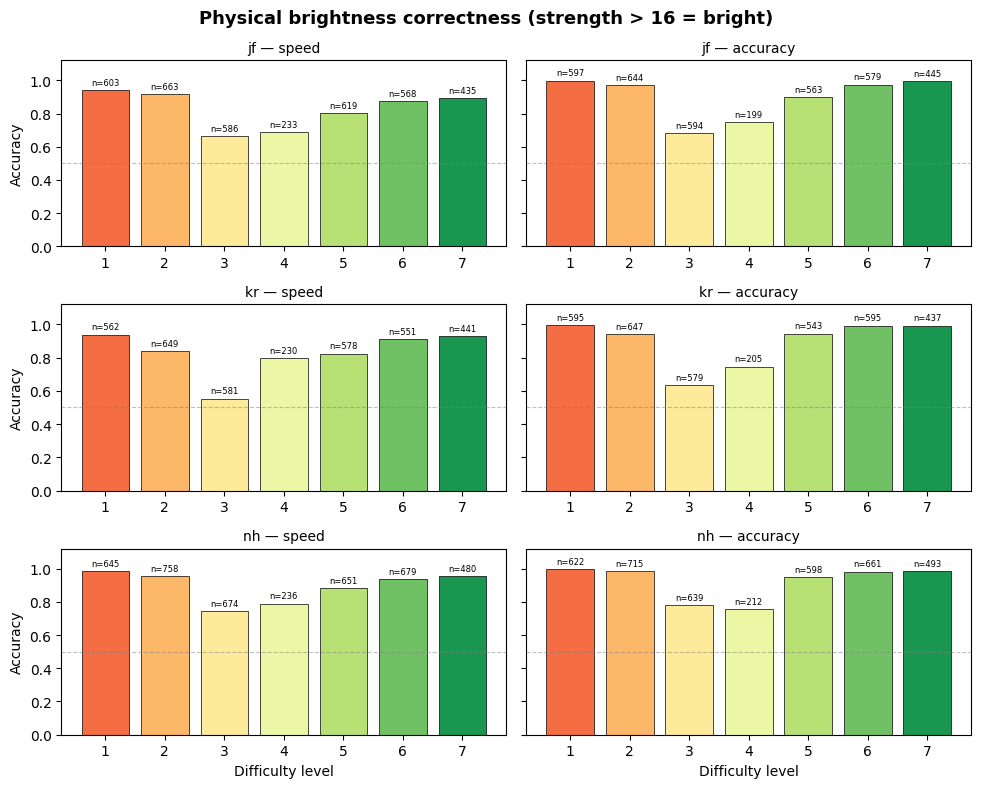

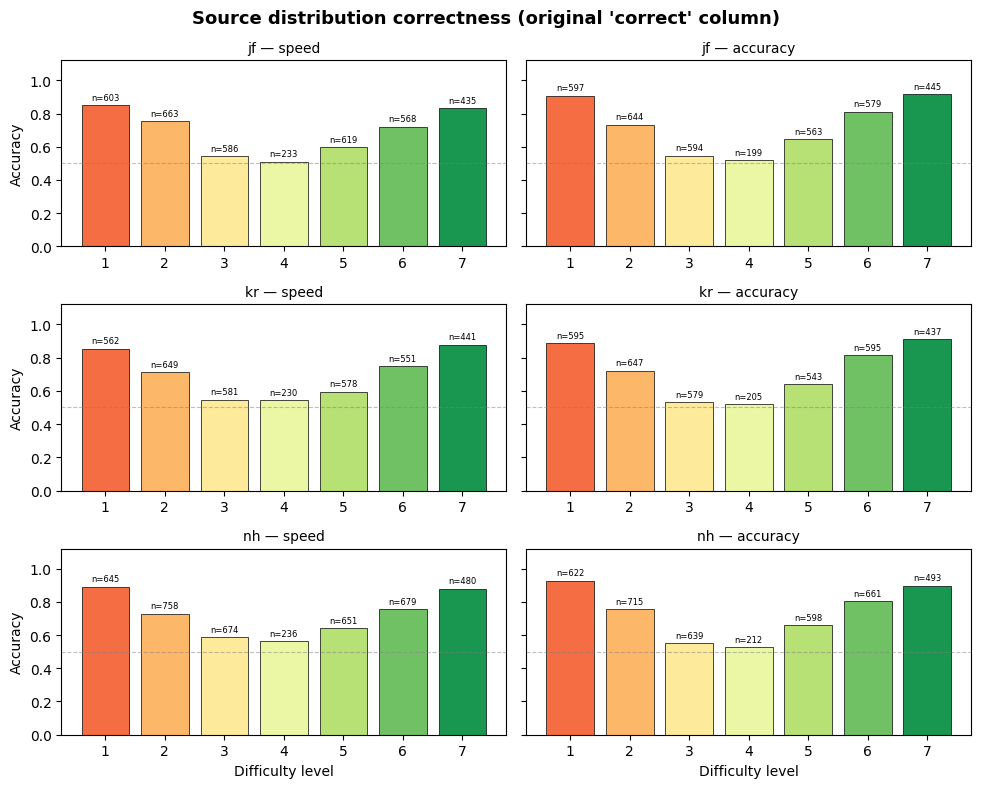

In [78]:
#!/usr/bin/env python3
"""
Compare two definitions of correctness in rr98:
  1. "Physical" correctness: did the participant correctly identify whether
     the stimulus was physically bright (strength > 16) or dark (strength < 16)?
  2. "Source" correctness: did the participant correctly identify which
     generating distribution the stimulus came from? (the original 'correct' column)

Produces two side-by-side figures, each a 3×2 grid (participants × instruction),
with bars showing accuracy per difficulty level.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── EDIT THIS ──
DATA_PATH = "rr98.csv"

PARTICIPANTS = ["jf", "kr", "nh"]
CONDITIONS   = ["speed", "accuracy"]


def load_data():
    df = pd.read_csv(DATA_PATH)
    df = df[df["outlier"] == False].copy()
    df["correct"] = df["correct"].astype(int)
    df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})

    def _qcut_levels(s, n_levels=7):
        return pd.qcut(s, q=n_levels, labels=False, duplicates="drop") + 1

    df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)

    # Physical correctness: brightness relative to midpoint (strength=16)
    # Exclude strength=16 (exactly ambiguous — 512 white, 512 black)
    df = df[df["strength"] != 16].copy()
    df["physically_bright"] = df["strength"] > 16
    df["responded_bright"]  = df["response"] == "light"
    df["phys_correct"]      = (df["physically_bright"] == df["responded_bright"]).astype(int)

    return df


def make_accuracy_plot(df, correct_col, title, filename=None):
    """Bar plot: accuracy per difficulty level, 3x2 grid (participants x instruction)."""
    fig, axes = plt.subplots(len(PARTICIPANTS), len(CONDITIONS),
                              figsize=(10, 8), sharey=True)
    plt.subplots_adjust(hspace=0.4, wspace=0.15)

    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 7))

    for i, pid in enumerate(PARTICIPANTS):
        for j, cond in enumerate(CONDITIONS):
            ax = axes[i, j]
            sub = df[(df["id"] == pid) & (df["instruction"] == cond)]

            acc = sub.groupby("diff_level").agg(
                accuracy=(correct_col, "mean"),
                n=("correct", "size")
            ).reset_index()

            bars = ax.bar(acc["diff_level"], acc["accuracy"], color=colors,
                          edgecolor="black", linewidth=0.5)

            # Add trial counts above each bar
            for idx, row in acc.iterrows():
                ax.text(row["diff_level"], row["accuracy"] + 0.02,
                        f'n={int(row["n"])}', ha="center", va="bottom", fontsize=6)

            ax.set_ylim(0, 1.12)
            ax.axhline(0.5, color="gray", ls="--", lw=0.8, alpha=0.5)
            ax.set_title(f"{pid} — {cond}", fontsize=10)
            ax.set_xticks(range(1, 8))

            if i == len(PARTICIPANTS) - 1:
                ax.set_xlabel("Difficulty level")
            if j == 0:
                ax.set_ylabel("Accuracy")

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()

    if filename:
        fig.savefig(filename, dpi=120, bbox_inches="tight")
        print(f"Saved: {filename}")

    return fig


def main():
    df = load_data()

    print(f"Total trials after excluding strength=16: {len(df)}")
    print(f"Overall source accuracy:   {df['correct'].mean():.3f}")
    print(f"Overall physical accuracy: {df['phys_correct'].mean():.3f}")

    # Show summary per participant
    print(f"\n{'pid':>4} {'source_acc':>11} {'phys_acc':>10} {'n_conflict':>11} "
          f"{'conflict_src':>13} {'conflict_phys':>14}")
    for pid in PARTICIPANTS:
        sub = df[df["id"] == pid]
        conflict = sub[sub["physically_bright"] != (sub["source"] == "light")]
        print(f"{pid:>4} {sub['correct'].mean():>11.3f} {sub['phys_correct'].mean():>10.3f} "
              f"{len(conflict):>11} {conflict['correct'].mean():>13.3f} "
              f"{conflict['phys_correct'].mean():>14.3f}")

    fig1 = make_accuracy_plot(df, "phys_correct",
                               "Physical brightness correctness (strength > 16 = bright)",
                               "accuracy_physical.png")

    fig2 = make_accuracy_plot(df, "correct",
                               "Source distribution correctness (original 'correct' column)",
                               "accuracy_source.png")

    plt.show()


if __name__ == "__main__":
    main()

Saved: accuracy_source_vs_physical.png


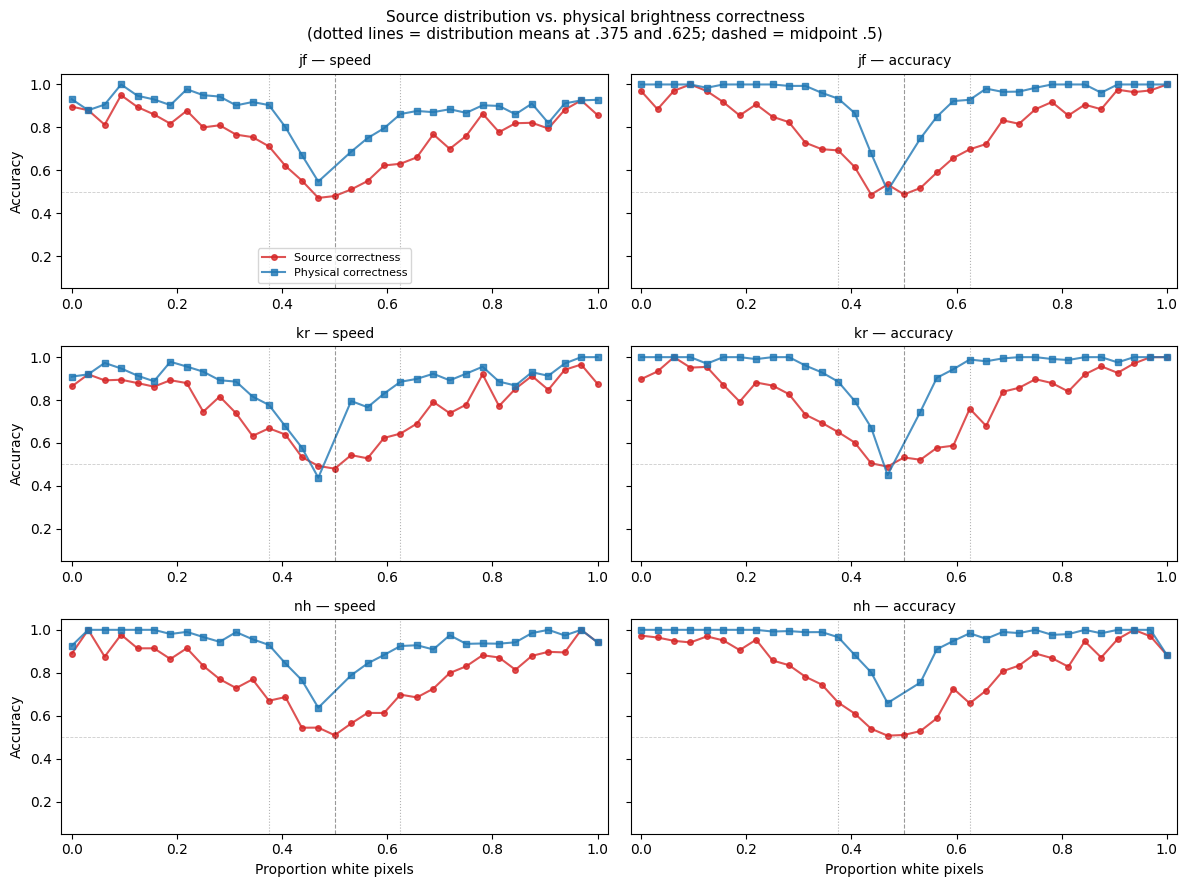

In [79]:
#!/usr/bin/env python3
"""
Source vs physical accuracy across all 33 strength levels.
Two curves per panel, 3x2 grid (participants x instruction).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "rr98.csv"
PARTICIPANTS = ["jf", "kr", "nh"]
CONDITIONS = ["speed", "accuracy"]


def main():
    df = pd.read_csv(DATA_PATH)
    df = df[df["outlier"] == False].copy()
    df["correct"] = df["correct"].astype(int)

    # Physical correctness (exclude strength=16)
    df["physically_bright"] = df["strength"] > 16
    df["responded_bright"] = df["response"] == "light"
    df["phys_correct"] = (df["physically_bright"] == df["responded_bright"]).astype(int)

    fig, axes = plt.subplots(len(PARTICIPANTS), len(CONDITIONS),
                              figsize=(12, 9), sharey=True)
    plt.subplots_adjust(hspace=0.35, wspace=0.12)

    for i, pid in enumerate(PARTICIPANTS):
        for j, cond in enumerate(CONDITIONS):
            ax = axes[i, j]
            sub = df[(df["id"] == pid) & (df["instruction"] == cond)]

            # Group by strength level
            grouped = sub.groupby("strength").agg(
                source_acc=("correct", "mean"),
                n=("correct", "size"),
            ).reset_index()

            # Physical accuracy — exclude strength=16
            sub_phys = sub[sub["strength"] != 16]
            phys_grouped = sub_phys.groupby("strength").agg(
                phys_acc=("phys_correct", "mean"),
            ).reset_index()

            # Proportion of white pixels
            grouped["proportion"] = grouped["strength"] / 32.0
            phys_grouped["proportion"] = phys_grouped["strength"] / 32.0

            # Plot both curves
            ax.plot(grouped["proportion"], grouped["source_acc"],
                    "o-", color="tab:red", ms=4, lw=1.5, alpha=0.8,
                    label="Source correctness")
            ax.plot(phys_grouped["proportion"], phys_grouped["phys_acc"],
                    "s-", color="tab:blue", ms=4, lw=1.5, alpha=0.8,
                    label="Physical correctness")

            # Mark the two distribution means and the midpoint
            ax.axvline(0.375, color="gray", ls=":", lw=0.8, alpha=0.6)
            ax.axvline(0.625, color="gray", ls=":", lw=0.8, alpha=0.6)
            ax.axvline(0.5, color="black", ls="--", lw=0.8, alpha=0.4)

            ax.axhline(0.5, color="gray", ls="--", lw=0.6, alpha=0.4)
            ax.set_ylim(0.05, 1.05)
            ax.set_xlim(-0.02, 1.02)
            ax.set_title(f"{pid} — {cond}", fontsize=10)

            if i == 0 and j == 0:
                ax.legend(fontsize=8, loc="lower center")
            if i == len(PARTICIPANTS) - 1:
                ax.set_xlabel("Proportion white pixels")
            if j == 0:
                ax.set_ylabel("Accuracy")

    fig.suptitle("Source distribution vs. physical brightness correctness\n"
                 "(dotted lines = distribution means at .375 and .625; "
                 "dashed = midpoint .5)",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig("accuracy_source_vs_physical.png", dpi=120, bbox_inches="tight")
    print("Saved: accuracy_source_vs_physical.png")
    plt.show()


if __name__ == "__main__":
    main()


=== jf ===
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
c[0]       -0.675  0.043  -0.748   -0.586      0.001    0.001    1520.0   
c[1]        0.510  0.035   0.443    0.570      0.001    0.001    1374.0   
B           4.650  0.220   4.235    5.057      0.005    0.003    1679.0   
t0          0.024  0.012   0.001    0.044      0.000    0.000    1370.0   
d_base[0]   0.763  0.031   0.707    0.824      0.001    0.000    2859.0   
d_base[1]   0.407  0.024   0.363    0.455      0.000    0.000    3403.0   
d_base[2]   0.066  0.022   0.023    0.106      0.000    0.000    2242.0   
d_base[3]   0.029  0.020   0.000    0.064      0.000    0.000    1607.0   
d_base[4]   0.190  0.024   0.145    0.234      0.000    0.000    3399.0   
d_base[5]   0.464  0.026   0.414    0.512      0.000    0.000    2855.0   
d_base[6]   0.674  0.033   0.613    0.737      0.001    0.000    2497.0   
r          17.878  0.746  16.638   19.452      0.018    0.012    1697.0   
p_lapse     0

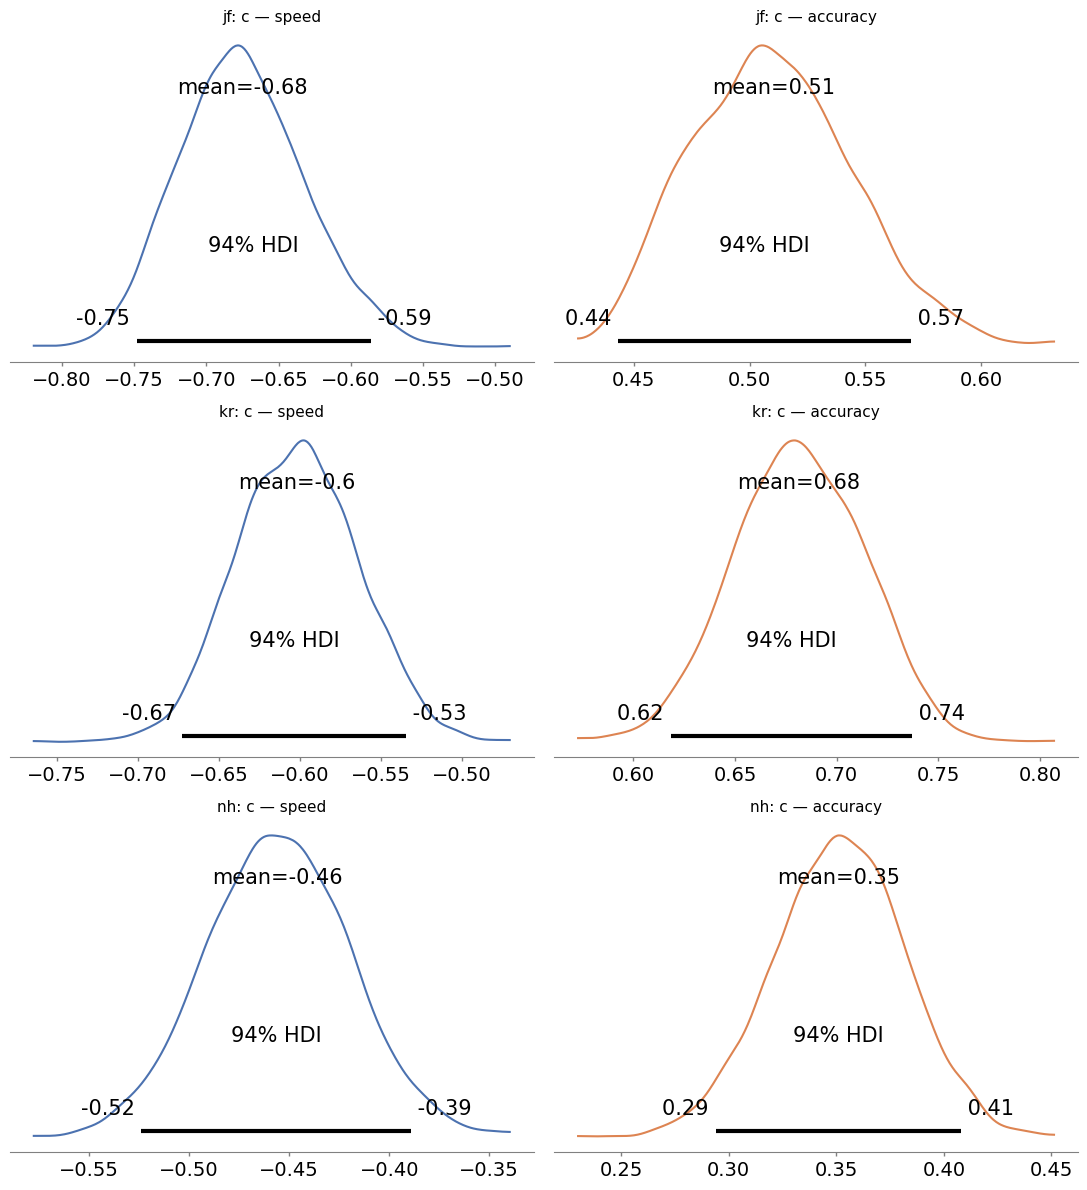

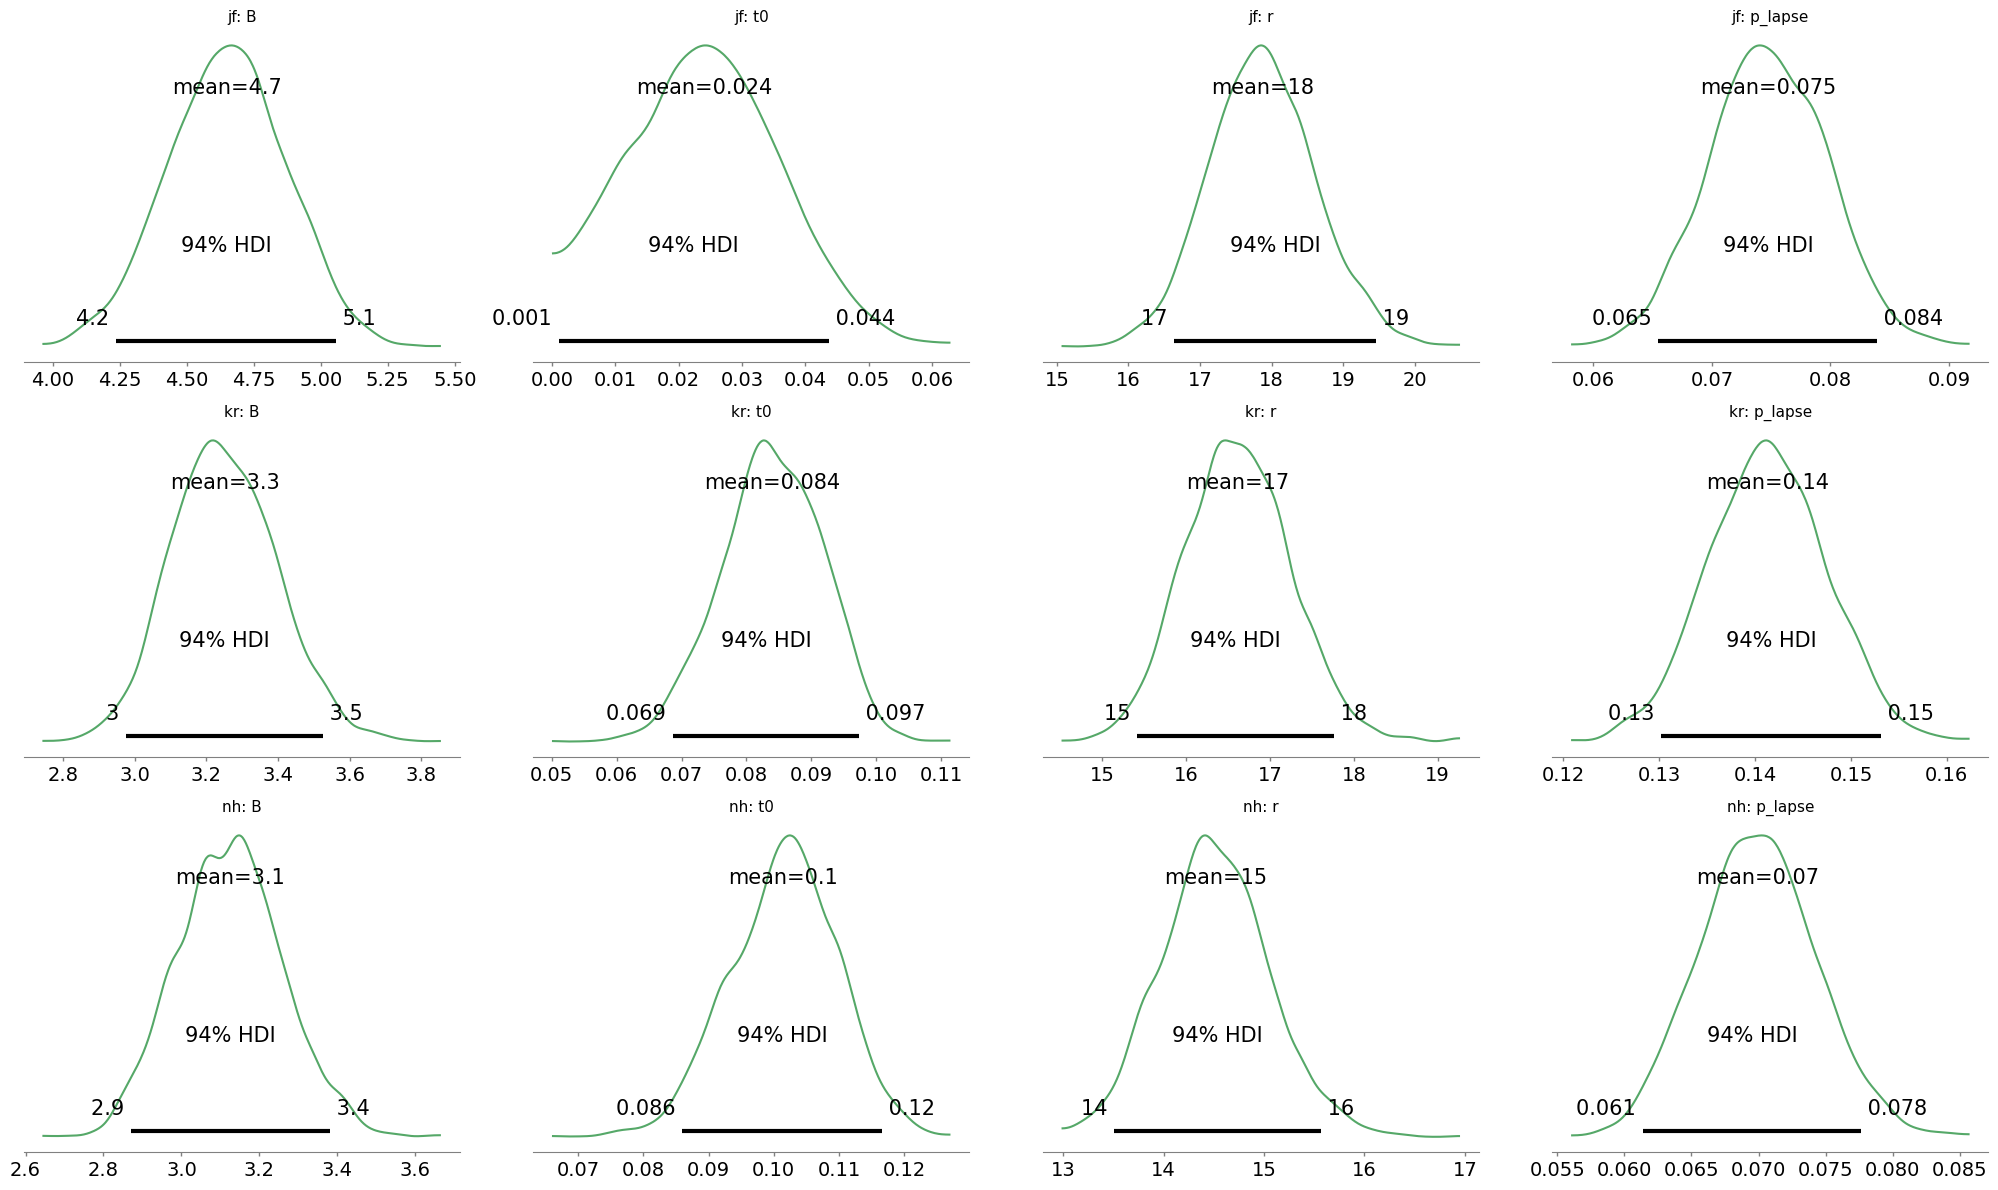

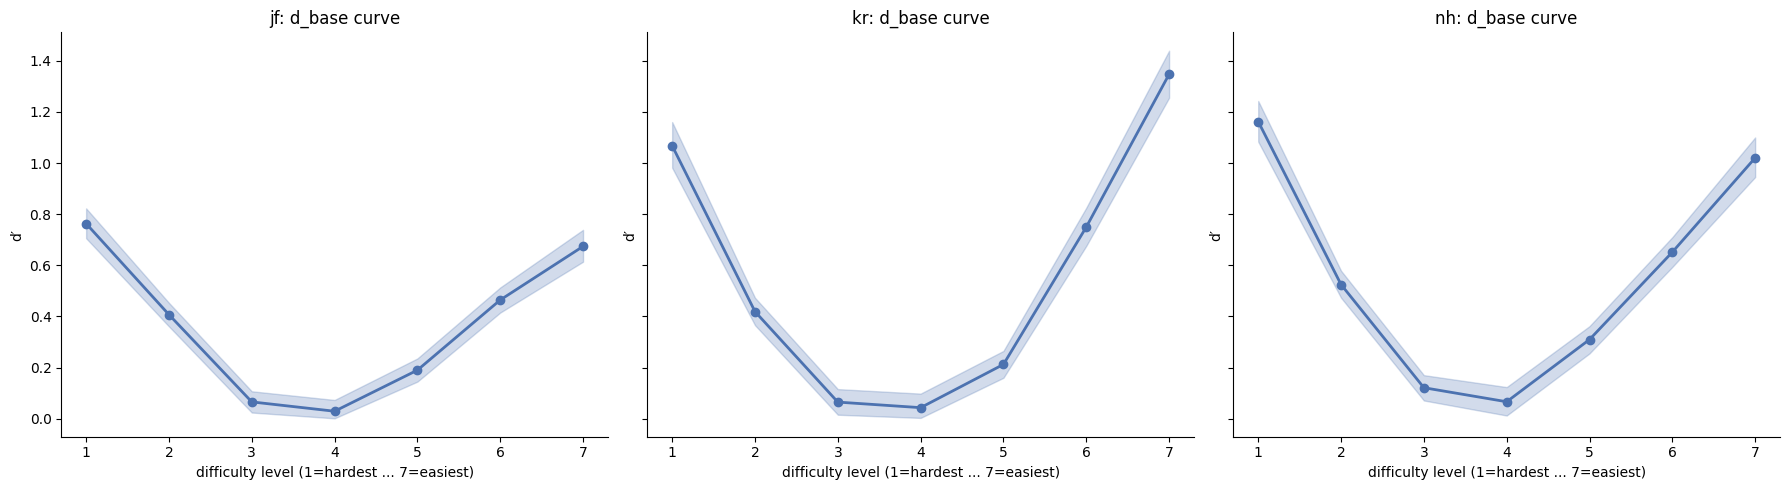

In [67]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

PARTICIPANTS = ["jf", "kr", "nh"]
IDATA_DIR = "Only1par/rr98_fits/idata"
cond_labels = ["speed", "accuracy"]

idata_c_only = {pid: az.from_netcdf(f"{IDATA_DIR}/c_only_{pid}.nc") for pid in PARTICIPANTS}

# --- summary table (no delta_d - c_only has no SAT-varying d' term) ---
for pid in PARTICIPANTS:
    print(f"\n=== {pid} ===")
    print(az.summary(idata_c_only[pid], var_names=["c", "B", "t0", "d_base", "r", "p_lapse"]))

# --- c[speed] vs c[accuracy], per participant ---
fig, axes = plt.subplots(len(PARTICIPANTS), 2, figsize=(11, 4 * len(PARTICIPANTS)))
colors = ["#4C72B0", "#DD8452"]

for row, pid in enumerate(PARTICIPANTS):
    for j, cond in enumerate(cond_labels):
        az.plot_posterior(idata_c_only[pid], var_names=["c"], coords={"c_dim_0": [j]},
                           ax=axes[row, j], color=colors[j])
        axes[row, j].set_title(f"{pid}: c — {cond}", fontsize=11)

plt.tight_layout()
plt.savefig("c_only_c_posteriors.png", dpi=150)
plt.show()

# --- B, t0, r, p_lapse: all scalars in c_only, one row per participant ---
scalar_vars = ["B", "t0", "r", "p_lapse"]
fig, axes = plt.subplots(len(PARTICIPANTS), len(scalar_vars), figsize=(20, 4 * len(PARTICIPANTS)))

for row, pid in enumerate(PARTICIPANTS):
    for col, var in enumerate(scalar_vars):
        az.plot_posterior(idata_c_only[pid], var_names=[var], ax=axes[row, col], color="#55A868")
        axes[row, col].set_title(f"{pid}: {var}", fontsize=11)

plt.tight_layout()
plt.savefig("c_only_scalar_posteriors.png", dpi=150)
plt.show()

# --- d_base difficulty curve (7 levels), per participant ---
# no speed/accuracy split here - d_base is shared across SAT in c_only
fig, axes = plt.subplots(1, len(PARTICIPANTS), figsize=(6 * len(PARTICIPANTS), 5), sharey=True)

for ax, pid in zip(axes, PARTICIPANTS):
    d_base_samples = idata_c_only[pid].posterior["d_base"].values.reshape(-1, 7)
    means = d_base_samples.mean(axis=0)
    lo = np.percentile(d_base_samples, 3, axis=0)
    hi = np.percentile(d_base_samples, 97, axis=0)

    levels = np.arange(1, 8)
    ax.plot(levels, means, marker="o", color="#4C72B0", linewidth=2)
    ax.fill_between(levels, lo, hi, alpha=0.25, color="#4C72B0")
    ax.set_xlabel("difficulty level (1=hardest ... 7=easiest)")
    ax.set_ylabel("d′")
    ax.set_title(f"{pid}: d_base curve", fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("c_only_d_base_curves.png", dpi=150)
plt.show()


=== jf ===
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
c         -0.525  0.097  -0.618   -0.322      0.041    0.044      10.0   
B          1.654  0.364   0.909    2.020      0.162    0.087       6.0   
t0[0]      0.010  0.019   0.000    0.053      0.009    0.010       6.0   
t0[1]      0.230  0.001   0.228    0.233      0.001    0.000       7.0   
d_base[0]  1.901  0.134   1.616    2.119      0.050    0.026       8.0   
d_base[1]  1.440  0.107   1.277    1.642      0.040    0.015       7.0   
d_base[2]  0.763  0.139   0.519    1.011      0.054    0.027       7.0   
d_base[3]  0.666  0.268   0.391    1.233      0.128    0.075       6.0   
d_base[4]  1.040  0.120   0.847    1.221      0.050    0.010       6.0   
d_base[5]  1.485  0.091   1.357    1.683      0.028    0.011      11.0   
d_base[6]  1.845  0.136   1.588    2.099      0.049    0.025       8.0   
delta_d   -0.709  0.102  -0.870   -0.483      0.041    0.024       7.0   
r          5.289  1.154   

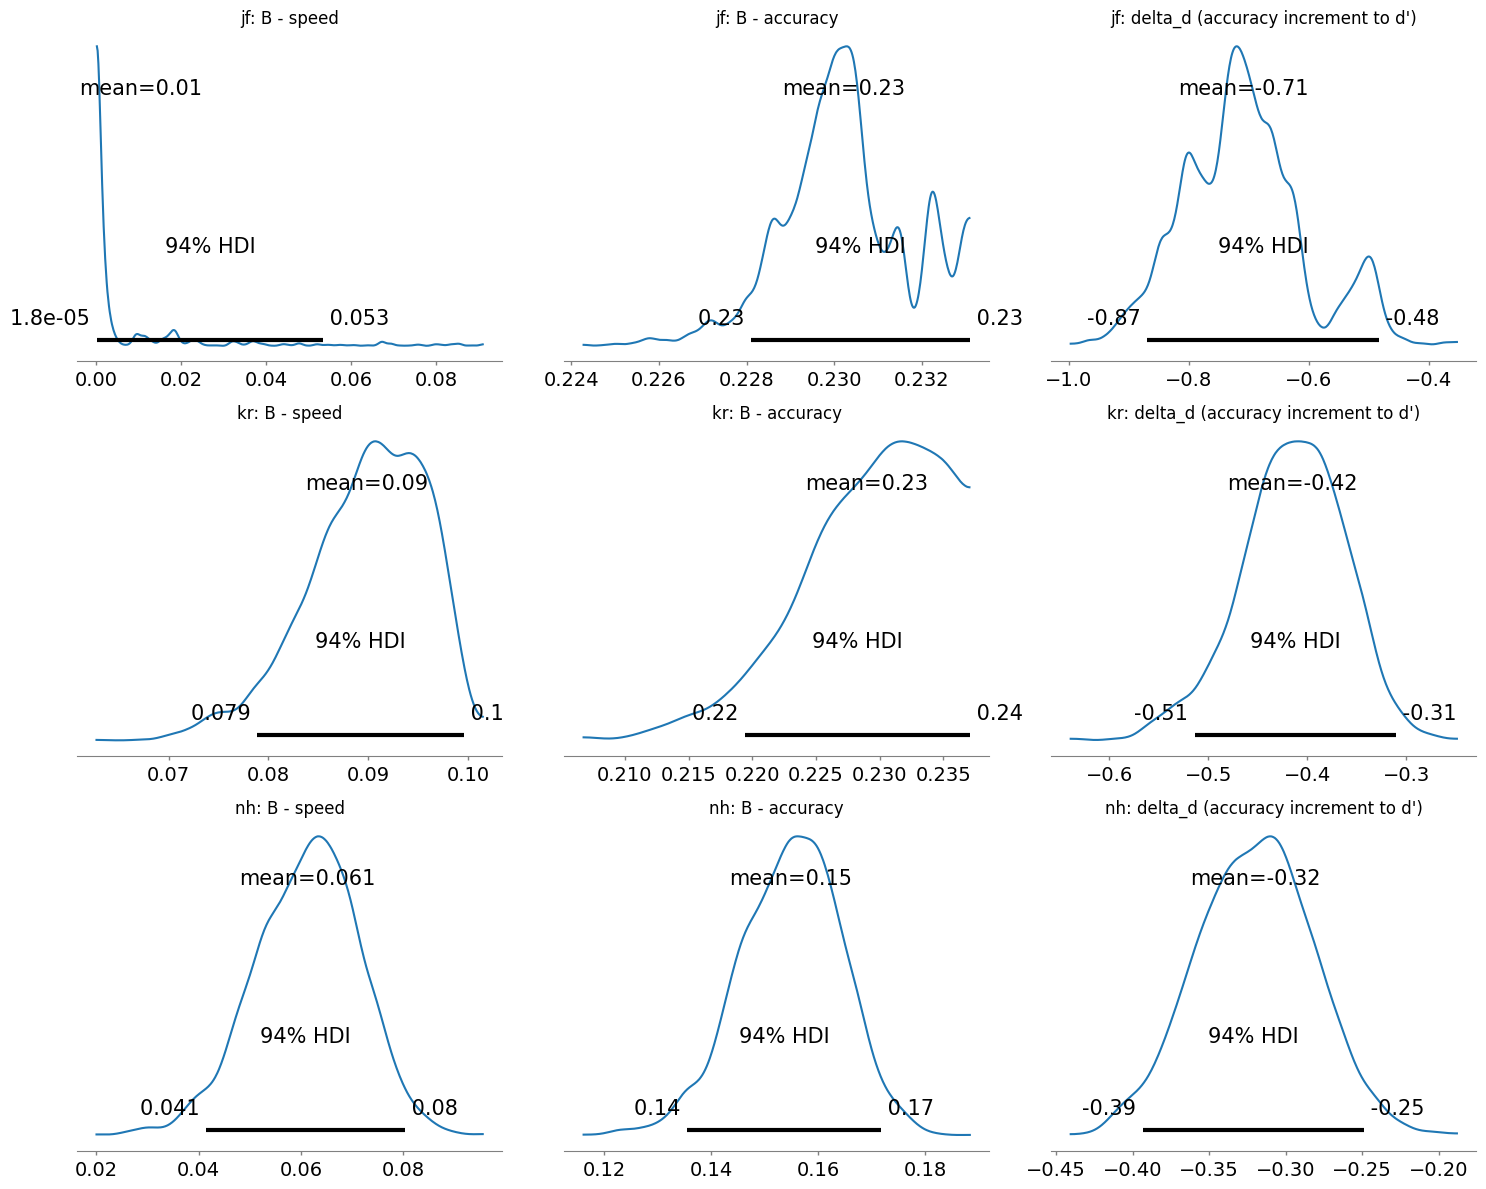

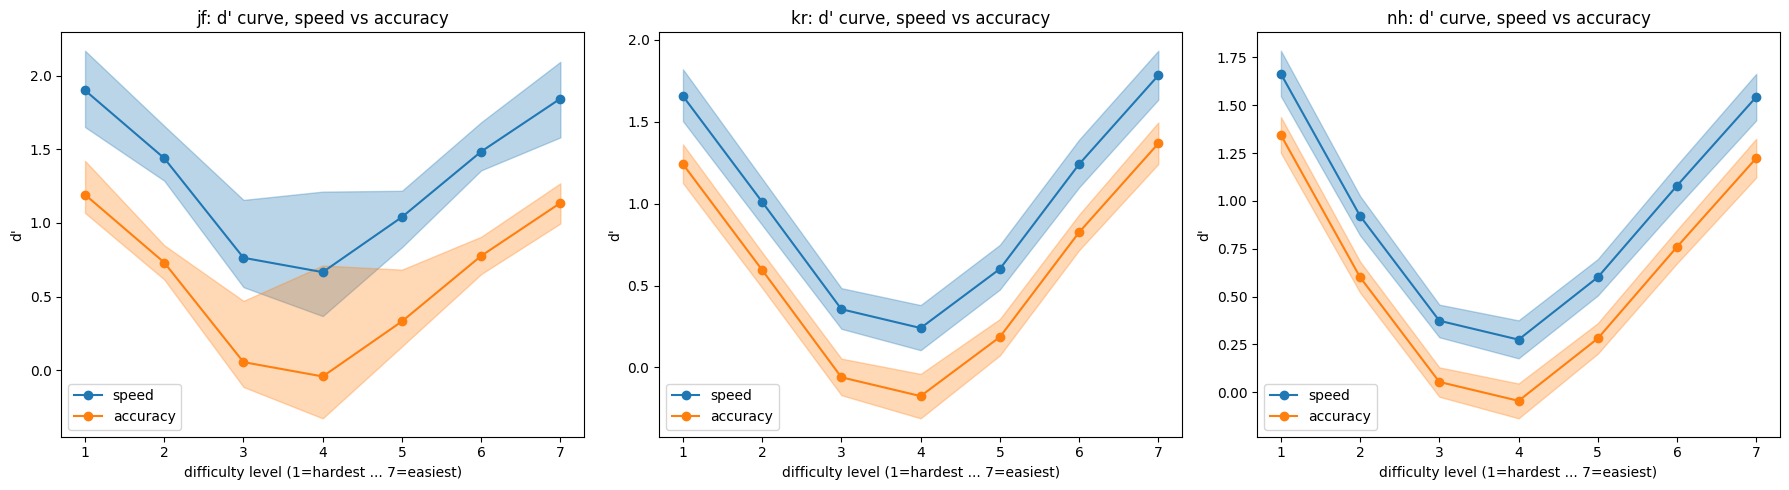

In [23]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

PARTICIPANTS = ["jf", "kr", "nh"]
IDATA_DIR = "rr98_fits/idata"

idata_d_B = {pid: az.from_netcdf(f"{IDATA_DIR}/d_t0_{pid}.nc") for pid in PARTICIPANTS}

# --- summary table, now including delta_d ---
for pid in PARTICIPANTS:
    print(f"\n=== {pid} ===")
    print(az.summary(idata_d_B[pid], var_names=["c", "B", "t0", "d_base", "delta_d", "r", "p_lapse"]))

# --- B[speed] vs B[accuracy], and delta_d, per participant ---
fig, axes = plt.subplots(len(PARTICIPANTS), 3, figsize=(15, 4 * len(PARTICIPANTS)))
cond_labels = ["speed", "accuracy"]

for row, pid in enumerate(PARTICIPANTS):
    for j, cond in enumerate(cond_labels):
        az.plot_posterior(idata_d_B[pid], var_names=["t0"], coords={"t0_dim_0": [j]},
                           ax=axes[row, j])
        axes[row, j].set_title(f"{pid}: B - {cond}")

    az.plot_posterior(idata_d_B[pid], var_names=["delta_d"], ax=axes[row, 2])
    axes[row, 2].set_title(f"{pid}: delta_d (accuracy increment to d')")

plt.tight_layout()
plt.show()

# --- d_base (speed) curve vs. d_base + delta_d (accuracy) curve, overlaid ---
fig, axes = plt.subplots(1, len(PARTICIPANTS), figsize=(6 * len(PARTICIPANTS), 5))

for ax, pid in zip(axes, PARTICIPANTS):
    d_base_samples = idata_d_B[pid].posterior["d_base"].values.reshape(-1, 7)
    delta_d_samples = idata_d_B[pid].posterior["delta_d"].values.reshape(-1, 1)

    speed_curve = d_base_samples
    accuracy_curve = d_base_samples + delta_d_samples  # broadcasts across the 7 levels

    levels = np.arange(1, 8)
    ax.plot(levels, speed_curve.mean(axis=0), marker="o", label="speed", color="C0")
    ax.fill_between(levels, np.percentile(speed_curve, 3, axis=0),
                     np.percentile(speed_curve, 97, axis=0), alpha=0.3, color="C0")

    ax.plot(levels, accuracy_curve.mean(axis=0), marker="o", label="accuracy", color="C1")
    ax.fill_between(levels, np.percentile(accuracy_curve, 3, axis=0),
                     np.percentile(accuracy_curve, 97, axis=0), alpha=0.3, color="C1")

    ax.set_xlabel("difficulty level (1=hardest ... 7=easiest)")
    ax.set_ylabel("d'")
    ax.set_title(f"{pid}: d' curve, speed vs accuracy")
    ax.legend()

plt.tight_layout()
plt.show()

In [66]:
import arviz as az
import pandas as pd

PARTICIPANTS = ["jf", "kr", "nh"]
MODELS = ["rr98_fits/idata/c_B", "rr98_fits/idata/c_t0", "rr98_fits/idata/d_B", "rr98_fits/idata/d_t0", "Only1par/rr98_fits/idata/c_only", "Only1par/rr98_fits/idata/B_only", "Only1par/rr98_fits/idata/t0_only", "Only1par/rr98_fits/idata/d_only", "Only1par/rr98_fits/idata/B_only", "Only1par/rr98_fits/idata/t0_only", "Only1par/rr98_fits_no_r/idata/c_only_no_r"]
IDATA_DIR = ""

wins = {m: 0 for m in MODELS}
decisive_wins = {m: 0 for m in MODELS}
per_participant_results = []

for pid in PARTICIPANTS:
    idatas = {}
    for m in MODELS:
        try:
            idatas[m] = az.from_netcdf(f"{m}_{pid}.nc")
        except FileNotFoundError:
            print(f"missing: {m}_{pid}.nc - skipping this model for {pid}")

    if len(idatas) < 2:
        continue

    comp = az.compare(idatas)
    comp["participant_id"] = pid
    per_participant_results.append(comp.reset_index())

    print(f"\n=== {pid} ===")
    print(comp[["rank", "elpd_loo", "p_loo", "elpd_diff", "dse", "warning"]])

    top_model = comp.index[0]
    wins[top_model] += 1

    # "decisive" win = margin over the runner-up exceeds 2x the runner-up's dse
    runner_up = comp.iloc[1]
    if runner_up["dse"] > 0 and runner_up["elpd_diff"] > 2 * runner_up["dse"]:
        decisive_wins[top_model] += 1

print("\nRaw win counts (top-ranked model per participant):")
print(wins)
print("\nDecisive win counts (margin > 2x dse):")
print(decisive_wins)

all_comparisons = pd.concat(per_participant_results)
all_comparisons.to_csv("rr98_fits/loo_comparison_all_participants.csv", index=False)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/s


=== jf ===
                                           rank     elpd_loo       p_loo  \
rr98_fits/idata/c_t0                          0  1327.470170   13.647254   
rr98_fits/idata/c_B                           1  1309.312296   13.945434   
Only1par/rr98_fits/idata/c_only               2  1305.976337   12.163279   
rr98_fits/idata/d_B                           3   887.785927   15.477825   
Only1par/rr98_fits/idata/B_only               4   844.714842   13.531237   
Only1par/rr98_fits_no_r/idata/c_only_no_r     5   632.971863   10.594480   
Only1par/rr98_fits/idata/t0_only              6  -328.163651  119.696325   
rr98_fits/idata/d_t0                          7  -368.089279  344.068283   
Only1par/rr98_fits/idata/d_only               8 -1025.429450   10.171591   

                                             elpd_diff        dse  warning  
rr98_fits/idata/c_t0                          0.000000   0.000000    False  
rr98_fits/idata/c_B                          18.157874   3.202102    Fals

nan
0
nan
nan


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


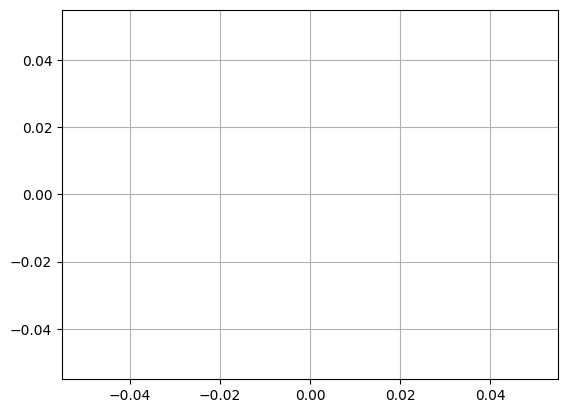

In [71]:
df = pd.read_csv("rr98.csv")
dude = "nk"
cond = "speed"
df[(df['id']==dude) & (df['instruction']==cond) & (df['correct']==True)]['rt'].hist(bins=100,density=True,alpha=0.5)
df[(df['id']==dude) & (df['instruction']==cond) & (df['correct']==False)]['rt'].hist(bins=100,density=True,alpha=0.5)
jf_speed = df[(df['id']==dude) & (df['instruction']==cond)]['rt']
print(jf_speed.quantile(0.05))
print((jf_speed < 0.15).sum())  # how many trials are faster than 150ms - implausible as genuine decisions

print(np.mean(df[(df['id']==dude) & (df['instruction']==cond) & (df['correct']==True)]['rt']))
print(np.mean(df[(df['id']==dude) & (df['instruction']==cond) & (df['correct']==False)]['rt']))

In [17]:
df = pd.read_csv("rr98.csv")
df[(df['id']=='nh') & (df['instruction']=="speed")]['rt'].describe()

count    4349.000000
mean        0.362777
std         0.079525
min         0.173000
25%         0.316000
50%         0.352000
75%         0.398000
max         2.208000
Name: rt, dtype: float64

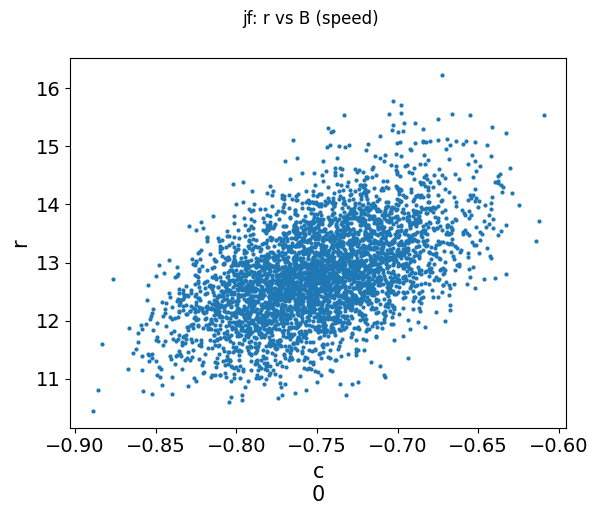

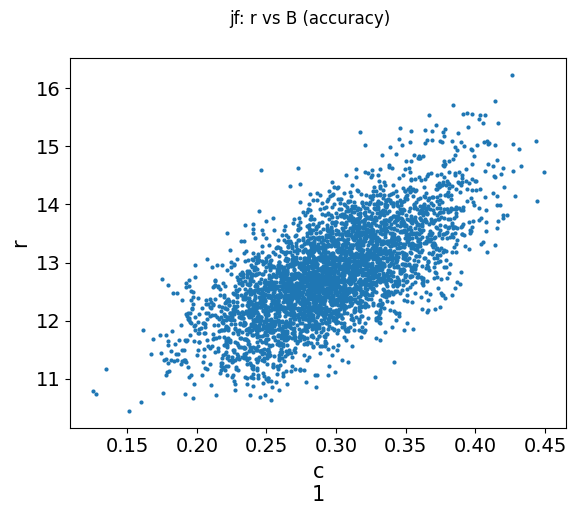

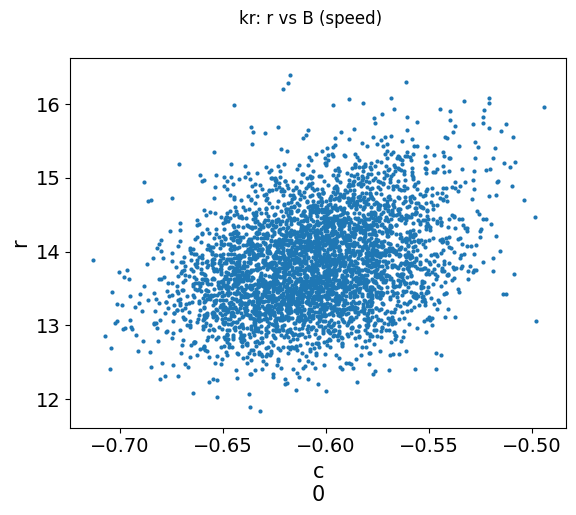

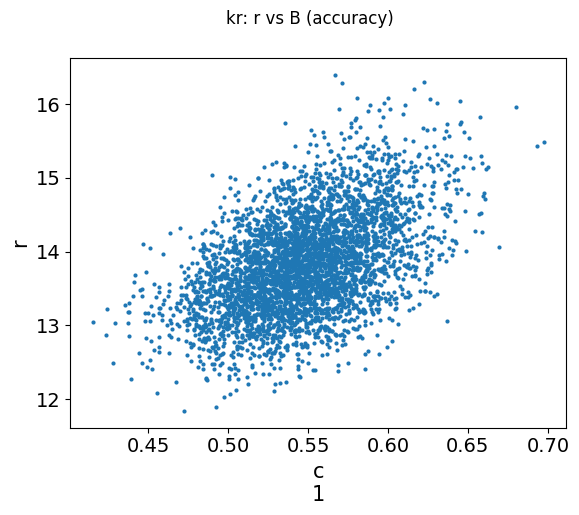

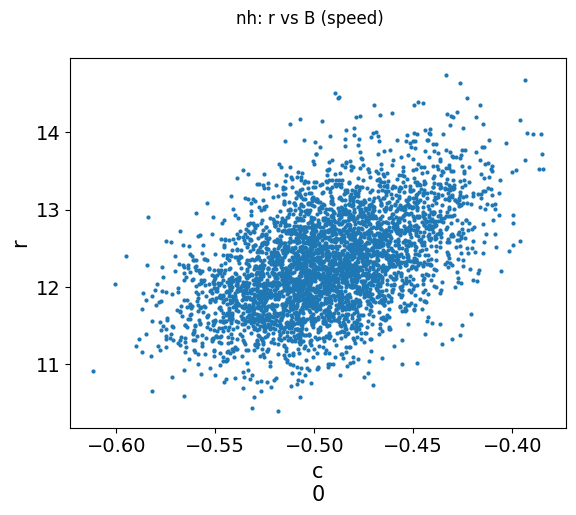

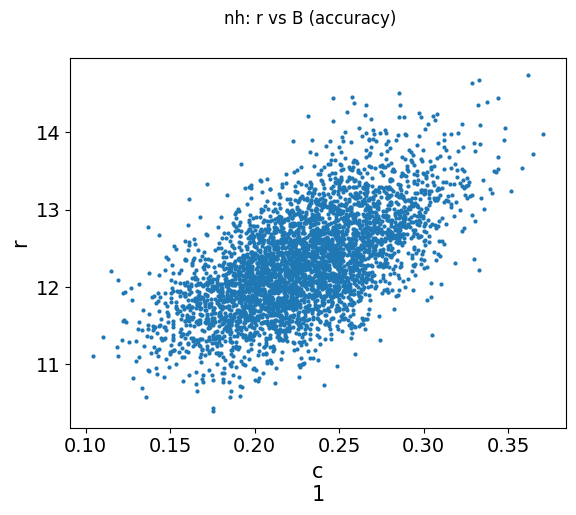

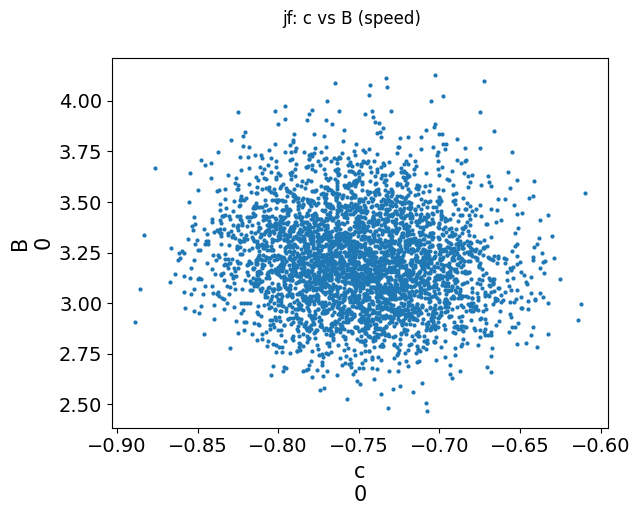

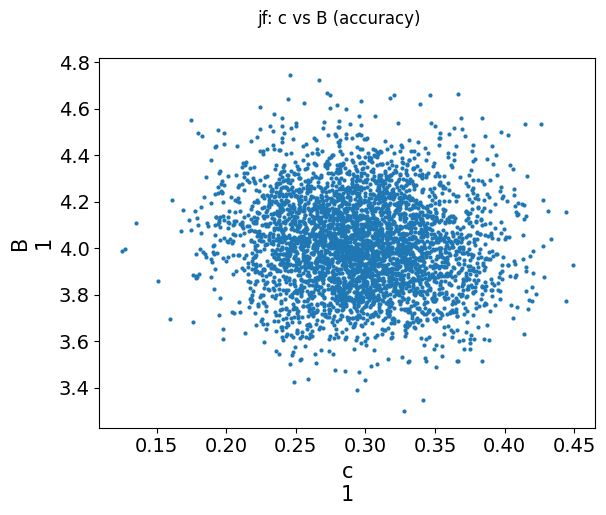

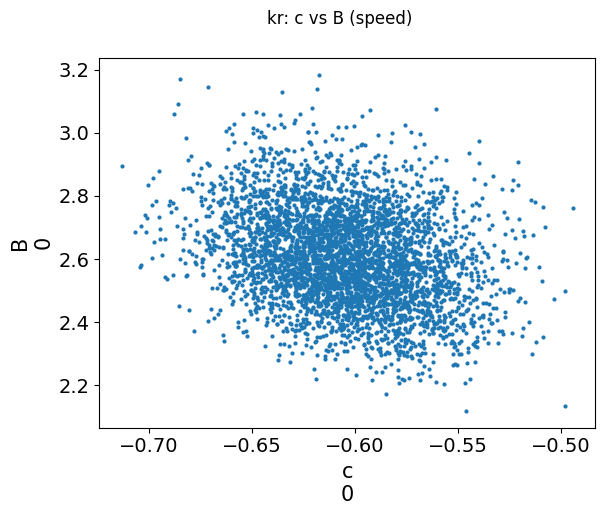

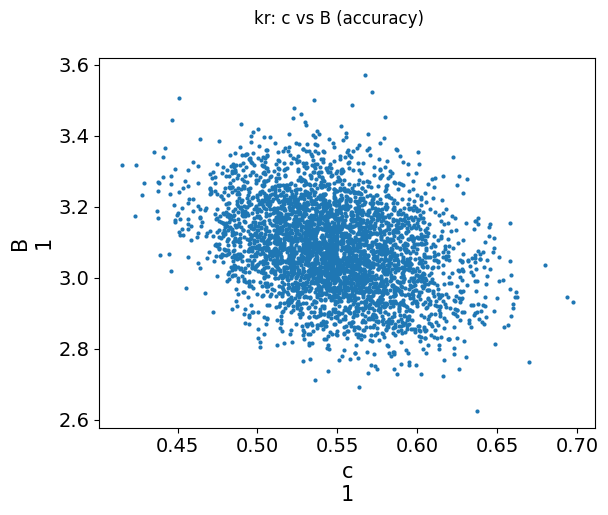

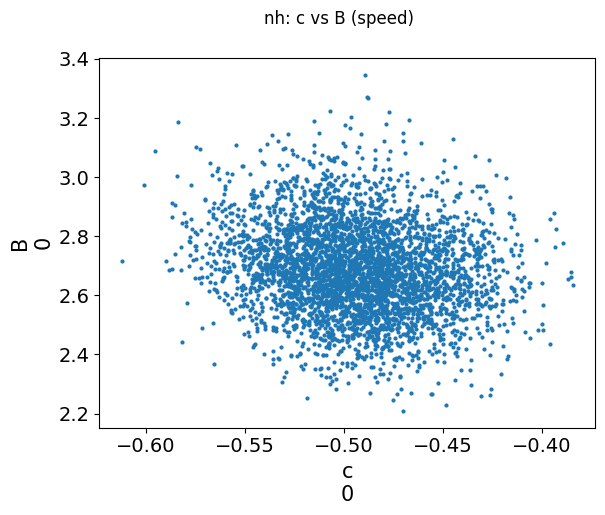

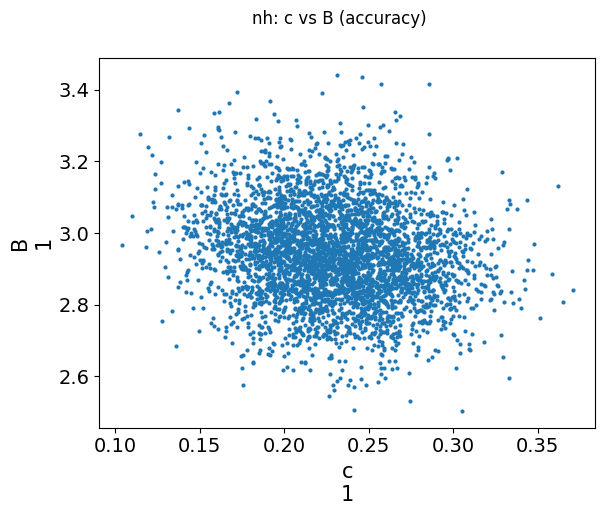

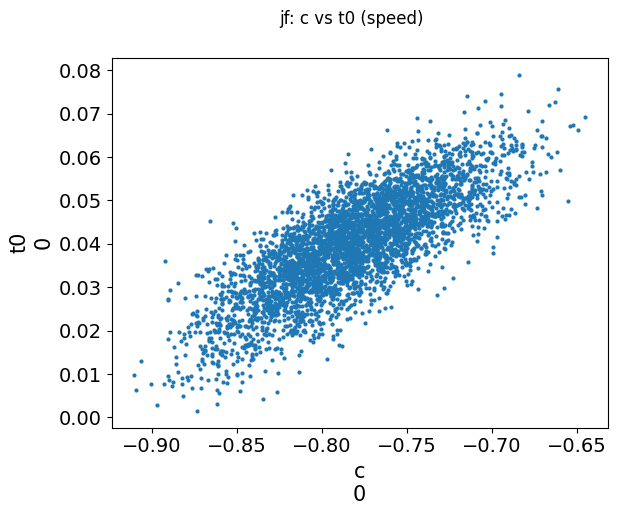

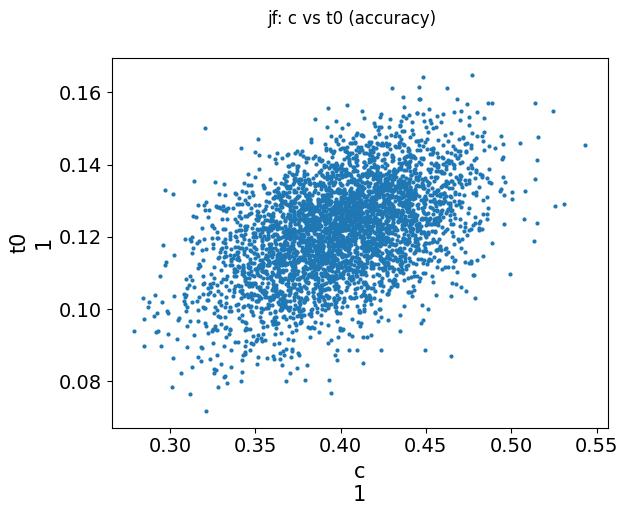

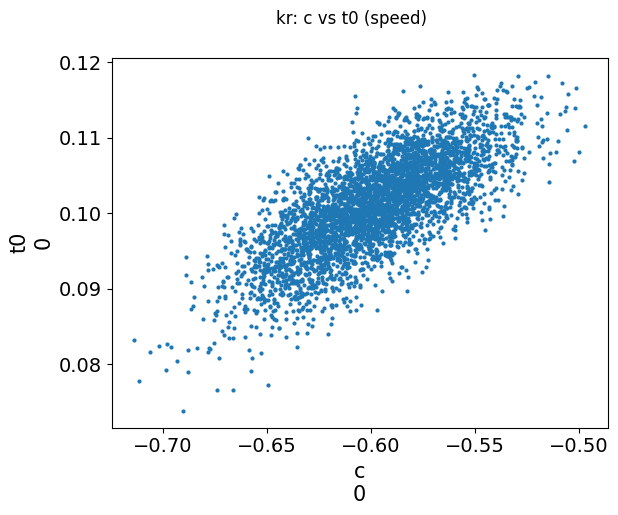

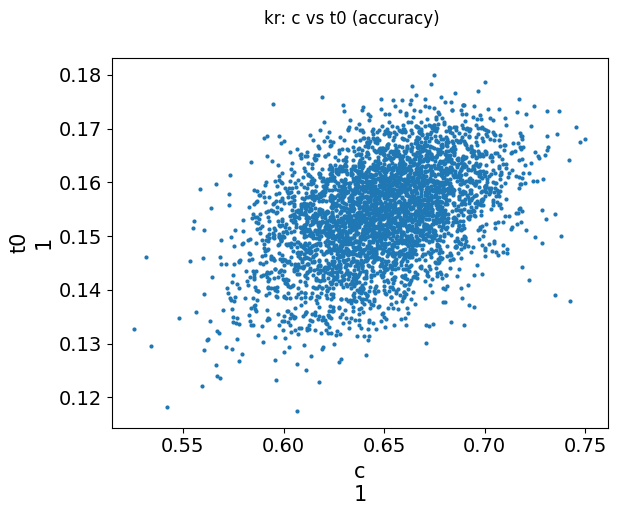

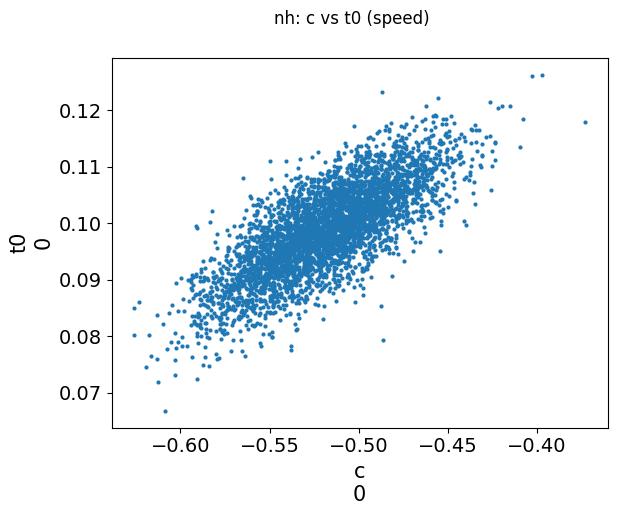

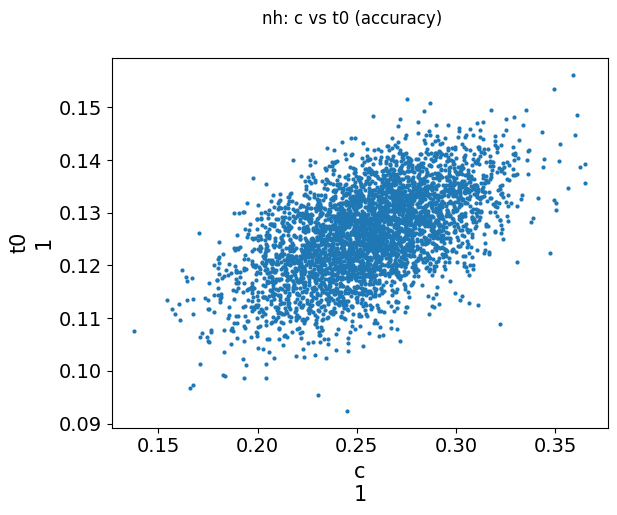

In [53]:
import arviz as az

PARTICIPANTS = ["jf", "kr", "nh"]
IDATA_DIR = "rr98_fits/idata"

idata_cB = {pid: az.from_netcdf(f"{IDATA_DIR}/c_B_{pid}.nc") for pid in PARTICIPANTS}
idata_ct0 = {pid: az.from_netcdf(f"{IDATA_DIR}/c_t0_{pid}.nc") for pid in PARTICIPANTS}

cond_labels = ["speed", "accuracy"]


# c vs B, per participant, per condition
for pid in PARTICIPANTS:
    for j, cond in enumerate(cond_labels):
        az.plot_pair(
            idata_cB[pid], var_names=["c", "r"],
            coords={"c_dim_0": [j]},
            kind="scatter", divergences=True,
        )
        import matplotlib.pyplot as plt
        plt.suptitle(f"{pid}: r vs B ({cond})")
        plt.show()


# c vs B, per participant, per condition
for pid in PARTICIPANTS:
    for j, cond in enumerate(cond_labels):
        az.plot_pair(
            idata_cB[pid], var_names=["c", "B"],
            coords={"c_dim_0": [j], "B_dim_0": [j]},
            kind="scatter", divergences=True,
        )
        import matplotlib.pyplot as plt
        plt.suptitle(f"{pid}: c vs B ({cond})")
        plt.show()

# c vs t0, per participant, per condition
for pid in PARTICIPANTS:
    for j, cond in enumerate(cond_labels):
        az.plot_pair(
            idata_ct0[pid], var_names=["c", "t0"],
            coords={"c_dim_0": [j], "t0_dim_0": [j]},
            kind="scatter", divergences=True,
        )
        plt.suptitle(f"{pid}: c vs t0 ({cond})")
        plt.show()



In [62]:
idata_ct0[pid].posterior["B"].values[:, :]

array([[2.6203664, 2.565531 , 2.5504712, ..., 2.4947875, 2.8299303,
        2.7897394],
       [2.8148952, 2.7051098, 2.7097658, ..., 2.5773728, 2.6099735,
        2.7831517],
       [2.5710079, 2.6157944, 2.5533998, ..., 2.6949642, 2.7746666,
        2.5489214],
       [2.6936497, 2.609697 , 2.8237064, ..., 2.656206 , 2.8290955,
        2.7797038]])

In [64]:
import arviz as az
import numpy as np
import pandas as pd

PARTICIPANTS = ["jf", "kr", "nh"]
IDATA_DIR = "rr98_fits/idata"
cond_labels = ["speed", "accuracy"]

idata_cB = {pid: az.from_netcdf(f"{IDATA_DIR}/c_B_{pid}.nc") for pid in PARTICIPANTS}
idata_ct0 = {pid: az.from_netcdf(f"{IDATA_DIR}/c_t0_{pid}.nc") for pid in PARTICIPANTS}


def flat(idata, var, j):
    """Flatten a (chain, draw) posterior array for var[j] into 1D."""
    return idata.posterior[var].values[:, :, j].flatten()


rows = []

for pid in PARTICIPANTS:
    for j, cond in enumerate(cond_labels):
        c_draws = flat(idata_cB[pid], "c", j)
        B_draws = flat(idata_cB[pid], "B", j)
        r_cB = np.corrcoef(c_draws, B_draws)[0, 1]

        rows.append({
            "participant_id": pid, "pair": "c_vs_B", "condition": cond,
            "pearson_r": r_cB, "n_draws": len(c_draws),
        })

    for j, cond in enumerate(cond_labels):
        c_draws = flat(idata_ct0[pid], "c", j)
        t0_draws = flat(idata_ct0[pid], "t0", j)
        r_ct0 = np.corrcoef(c_draws, t0_draws)[0, 1]

        rows.append({
            "participant_id": pid, "pair": "c_vs_t0", "condition": cond,
            "pearson_r": r_ct0, "n_draws": len(c_draws),
        })
    for j, cond in enumerate(cond_labels):
        c_draws = idata_ct0[pid].posterior["B"].values[:, :].flatten()
        t0_draws = idata_ct0[pid].posterior["r"].values[:, :].flatten()
        r_ct0 = np.corrcoef(c_draws, t0_draws)[0, 1]

        rows.append({
            "participant_id": pid, "pair": "B_vs_r", "condition": cond,
            "pearson_r": r_ct0, "n_draws": len(c_draws),
        })

corr_table = pd.DataFrame(rows)
corr_table = corr_table[["pair", "participant_id", "condition", "pearson_r", "n_draws"]]
corr_table = corr_table.sort_values(["pair", "participant_id", "condition"]).reset_index(drop=True)

print(corr_table.to_string(index=False))
corr_table.to_csv("rr98_fits/c_B_t0_correlations.csv", index=False)

   pair participant_id condition  pearson_r  n_draws
 B_vs_r             jf  accuracy   0.654225     4000
 B_vs_r             jf     speed   0.654225     4000
 B_vs_r             kr  accuracy   0.760829     4000
 B_vs_r             kr     speed   0.760829     4000
 B_vs_r             nh  accuracy   0.696784     4000
 B_vs_r             nh     speed   0.696784     4000
 c_vs_B             jf  accuracy  -0.076740     4000
 c_vs_B             jf     speed  -0.110319     4000
 c_vs_B             kr  accuracy  -0.328856     4000
 c_vs_B             kr     speed  -0.285030     4000
 c_vs_B             nh  accuracy  -0.178556     4000
 c_vs_B             nh     speed  -0.167620     4000
c_vs_t0             jf  accuracy   0.468264     4000
c_vs_t0             jf     speed   0.788566     4000
c_vs_t0             kr  accuracy   0.431357     4000
c_vs_t0             kr     speed   0.739379     4000
c_vs_t0             nh  accuracy   0.549307     4000
c_vs_t0             nh     speed   0.761387   

In [68]:
import arviz as az
import numpy as np
import pandas as pd

PARTICIPANTS = ["jf", "kr", "nh"]
IDATA_DIR = "rr98_fits/idata"
cond_labels = ["speed", "accuracy"]

idata_cB = {pid: az.from_netcdf(f"{IDATA_DIR}/c_B_{pid}.nc") for pid in PARTICIPANTS}
idata_ct0 = {pid: az.from_netcdf(f"{IDATA_DIR}/c_t0_{pid}.nc") for pid in PARTICIPANTS}


def flat(idata, var, j=None):
    """Flatten a (chain, draw[, j]) posterior array into 1D.
    j=None for scalar parameters, j=int for a specific vector index."""
    if j is None:
        return idata.posterior[var].values.flatten()
    return idata.posterior[var].values[:, :, j].flatten()


rows = []

for pid in PARTICIPANTS:
    for j, cond in enumerate(cond_labels):
        c_draws = flat(idata_cB[pid], "c", j)
        B_draws = flat(idata_cB[pid], "B", j)
        r_cB = np.corrcoef(c_draws, B_draws)[0, 1]
        rows.append({"participant_id": pid, "pair": "c_vs_B", "condition": cond,
                      "pearson_r": r_cB, "n_draws": len(c_draws)})

    for j, cond in enumerate(cond_labels):
        c_draws = flat(idata_ct0[pid], "c", j)
        t0_draws = flat(idata_ct0[pid], "t0", j)
        r_ct0 = np.corrcoef(c_draws, t0_draws)[0, 1]
        rows.append({"participant_id": pid, "pair": "c_vs_t0", "condition": cond,
                      "pearson_r": r_ct0, "n_draws": len(c_draws)})

    # B and r are both fixed scalars in c_t0 - one correlation per participant,
    # no condition split (neither parameter varies by SAT here)
    B_draws = flat(idata_ct0[pid], "B")
    r_draws = flat(idata_ct0[pid], "r")
    r_Br = np.corrcoef(B_draws, r_draws)[0, 1]
    rows.append({"participant_id": pid, "pair": "B_vs_r", "condition": "n/a (scalar)",
                  "pearson_r": r_Br, "n_draws": len(B_draws)})

corr_table = pd.DataFrame(rows)
corr_table = corr_table[["pair", "participant_id", "condition", "pearson_r", "n_draws"]]
corr_table = corr_table.sort_values(["pair", "participant_id", "condition"]).reset_index(drop=True)

print(corr_table.to_string(index=False))
corr_table.to_csv("rr98_fits/c_B_t0_correlations.csv", index=False)

   pair participant_id    condition  pearson_r  n_draws
 B_vs_r             jf n/a (scalar)   0.654225     4000
 B_vs_r             kr n/a (scalar)   0.760829     4000
 B_vs_r             nh n/a (scalar)   0.696784     4000
 c_vs_B             jf     accuracy  -0.076740     4000
 c_vs_B             jf        speed  -0.110319     4000
 c_vs_B             kr     accuracy  -0.328856     4000
 c_vs_B             kr        speed  -0.285030     4000
 c_vs_B             nh     accuracy  -0.178556     4000
 c_vs_B             nh        speed  -0.167620     4000
c_vs_t0             jf     accuracy   0.468264     4000
c_vs_t0             jf        speed   0.788566     4000
c_vs_t0             kr     accuracy   0.431357     4000
c_vs_t0             kr        speed   0.739379     4000
c_vs_t0             nh     accuracy   0.549307     4000
c_vs_t0             nh        speed   0.761387     4000
